In [2]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


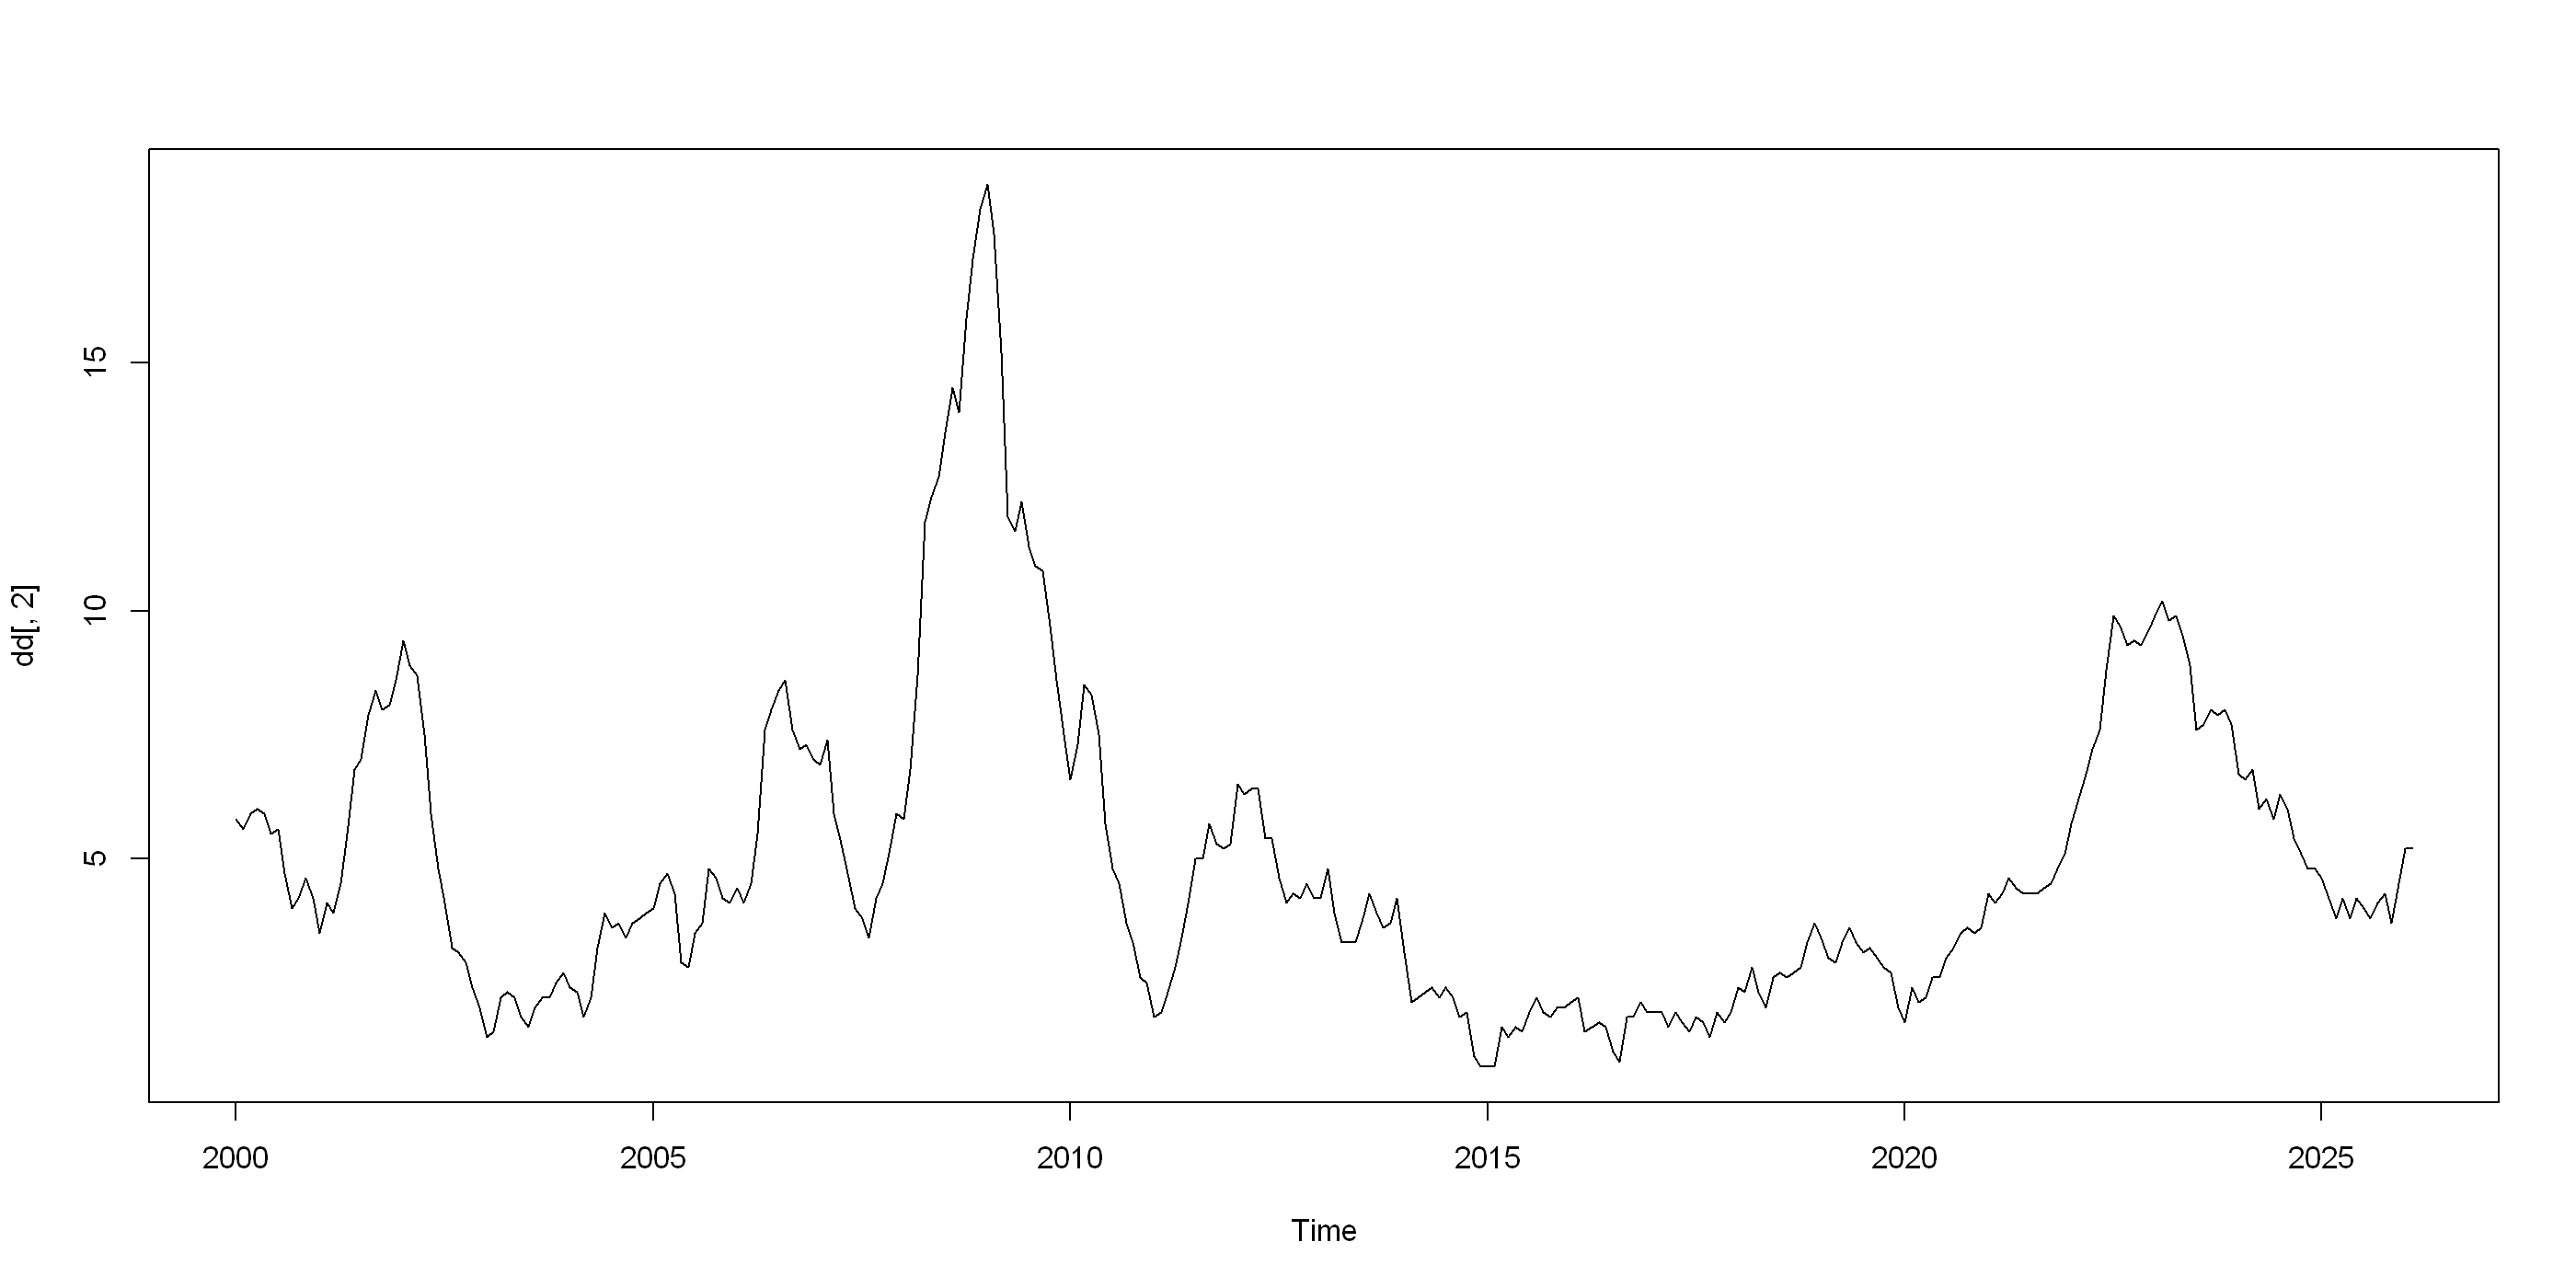

In [3]:
dd <- ts(read.csv("VIS01000 (2).csv",sep = ";"),start = c(2000,1),frequency = 12)
plot(dd[,2])
t.cpi <- ts(dd[,2])
n_x = length(t.cpi)
horizon = 0
t.cpiTrain <- window(t.cpi,end=n_x-horizon)

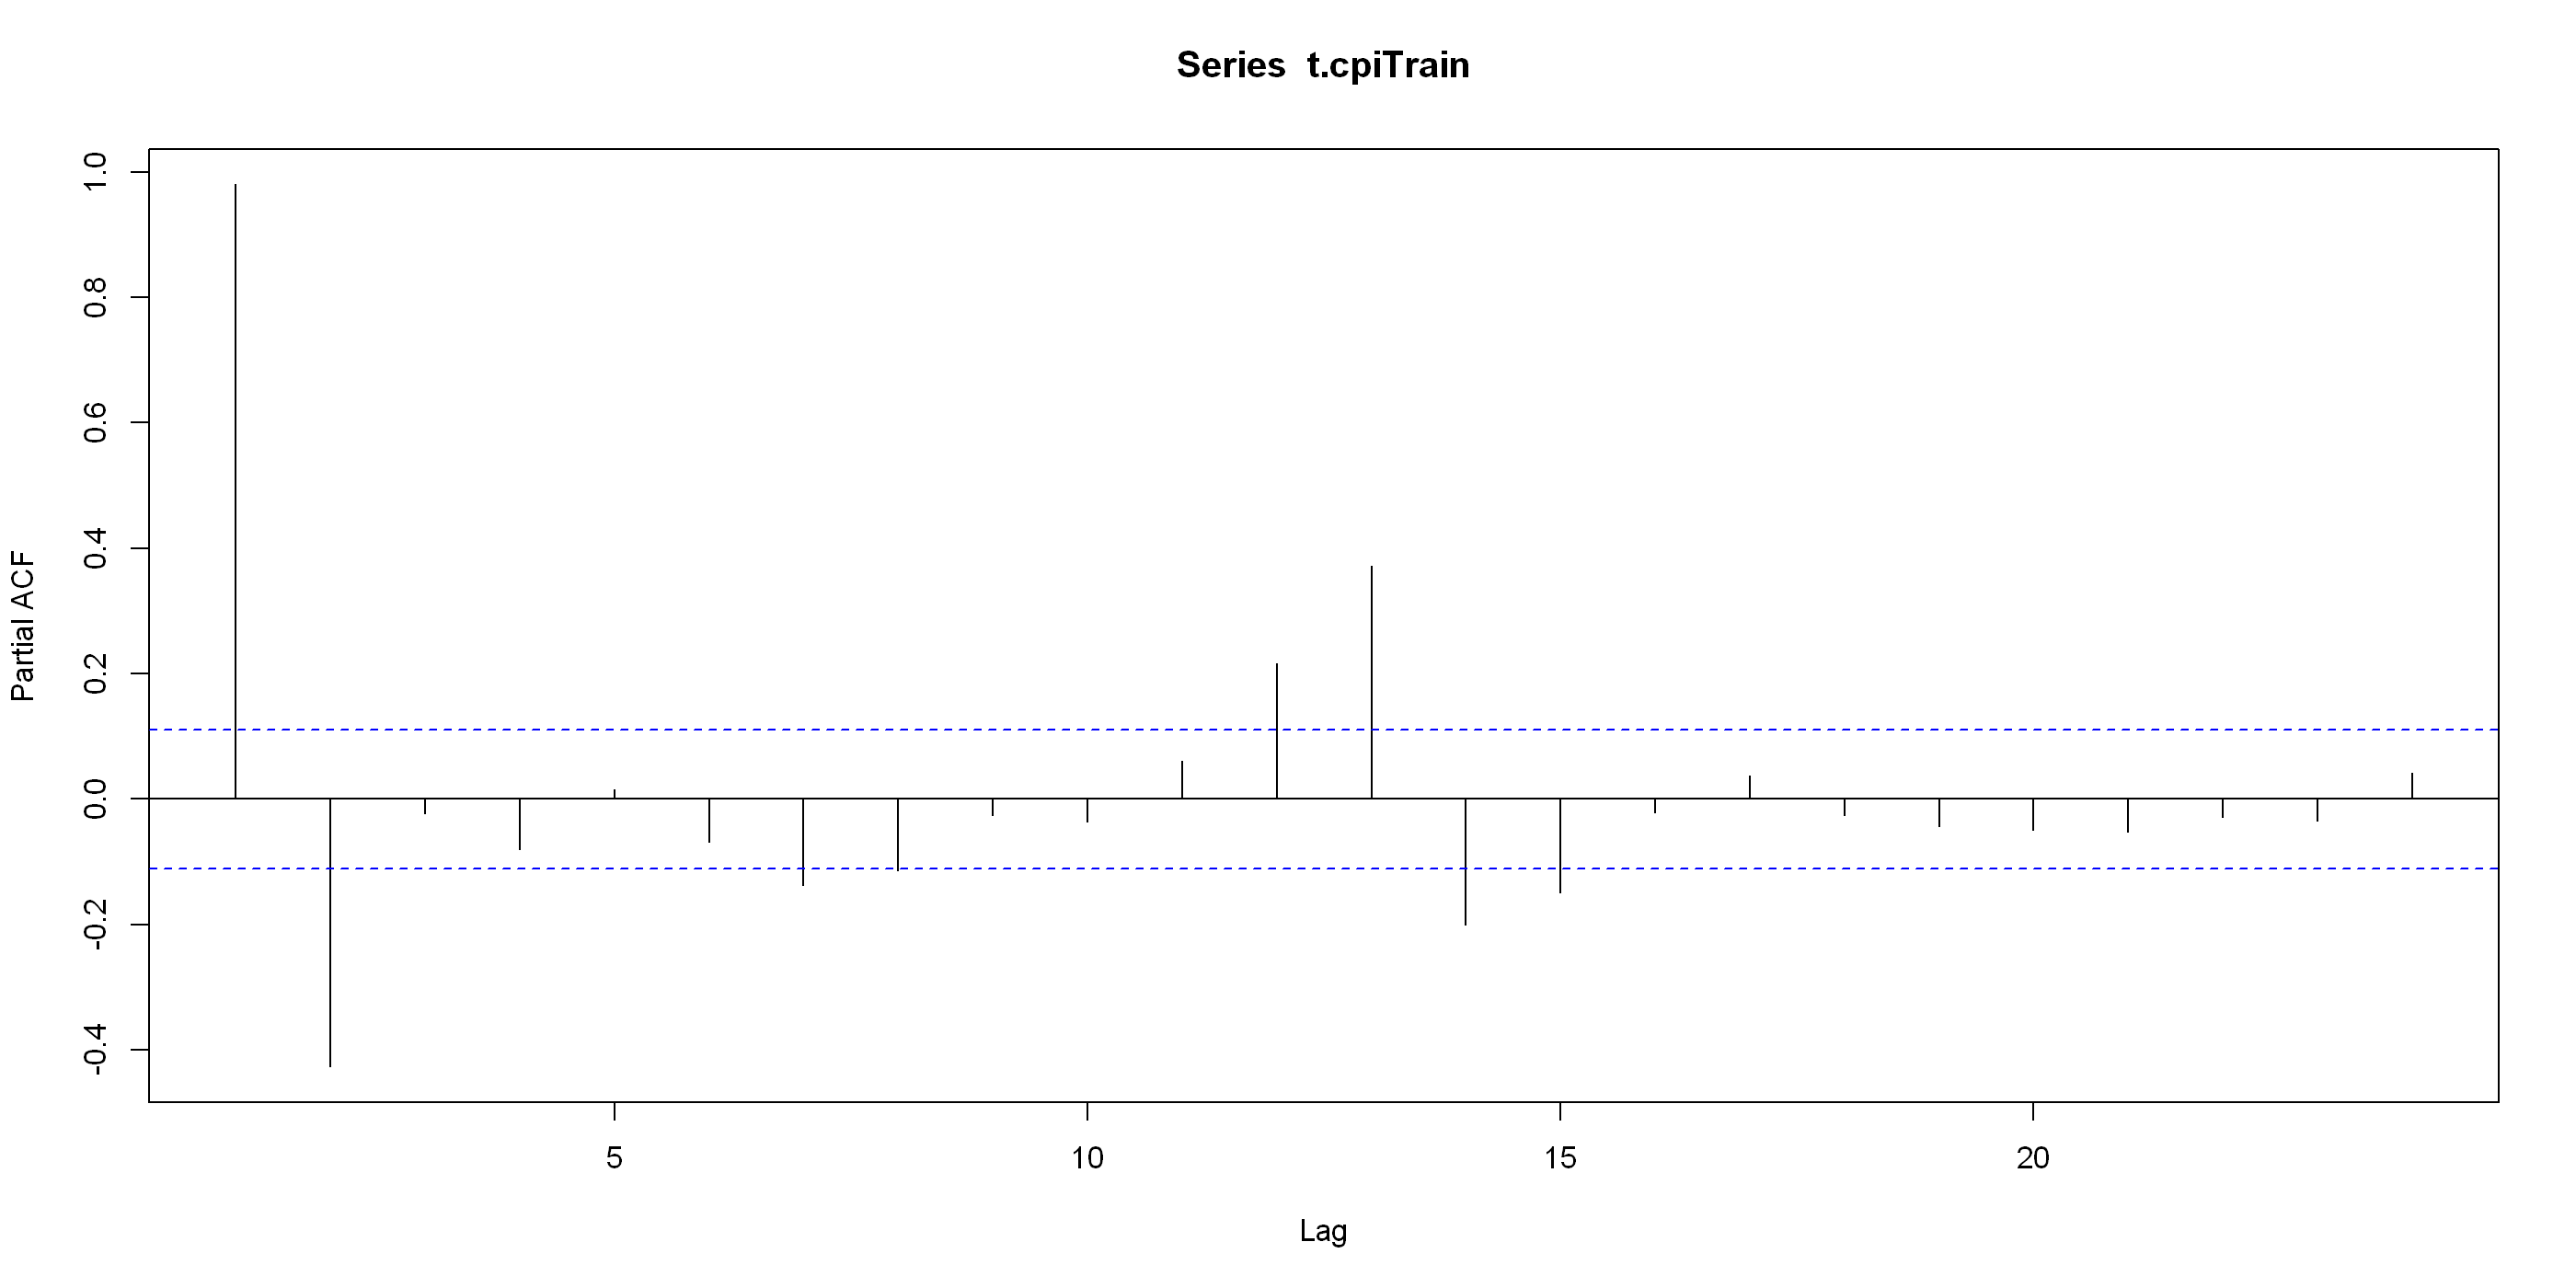

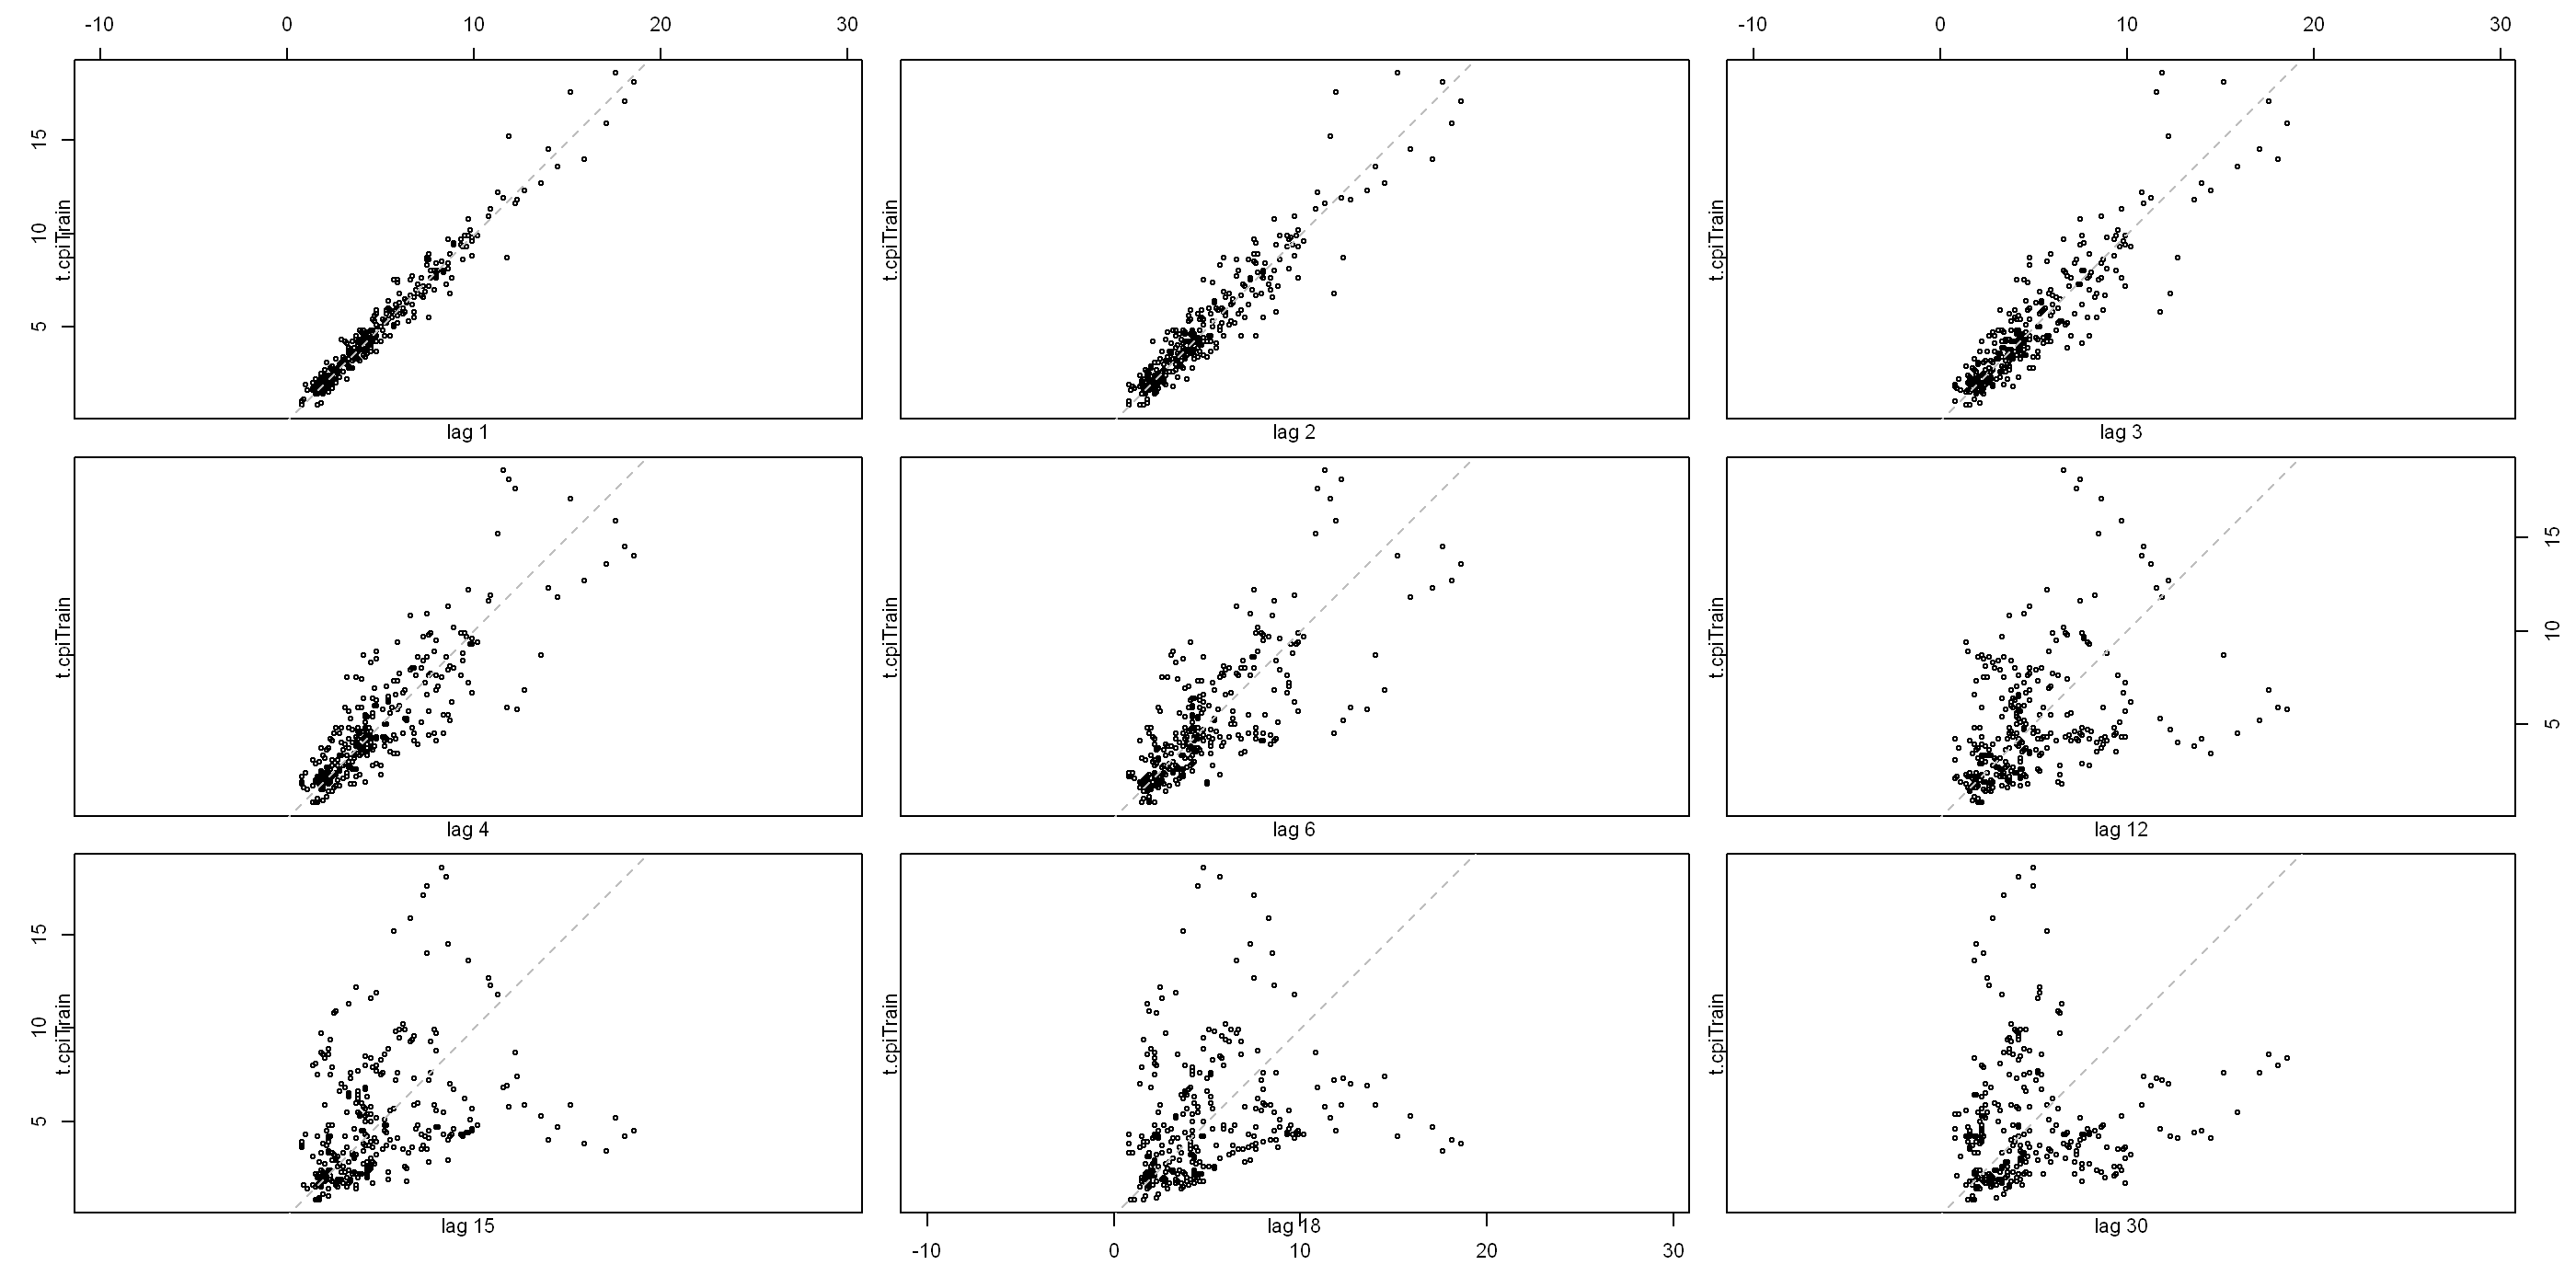

In [4]:
pacor =pacf(t.cpiTrain)
lag.plot(t.cpiTrain,set.lags = c(1,2,3,4,6,12,15,18,30))

In [5]:
alpha95=0.05
alpha99=0.01
alpha90 = 0.1
z95 = qnorm(1-alpha95/2)
z99 = qnorm(1-alpha99/2)
z90 = qnorm(1-alpha90/2)

In [6]:
p_grid <- c(6,9,12,15,18,24,30,36)
n_est = length(p_grid)
ar.cpi_vec <-vector(mode="list",length = n_est)
for(p in 1:n_est)
{
    ar.cpi_vec[[p]] <- arima(t.cpiTrain,order = c(p_grid[p],0,0),method="ML")
    # ar.cpi_cor[[p]] <- cor(ar.cpi_vec[[p]]$coef,pacor$acf[1:(p_grid[p]+1)])
}


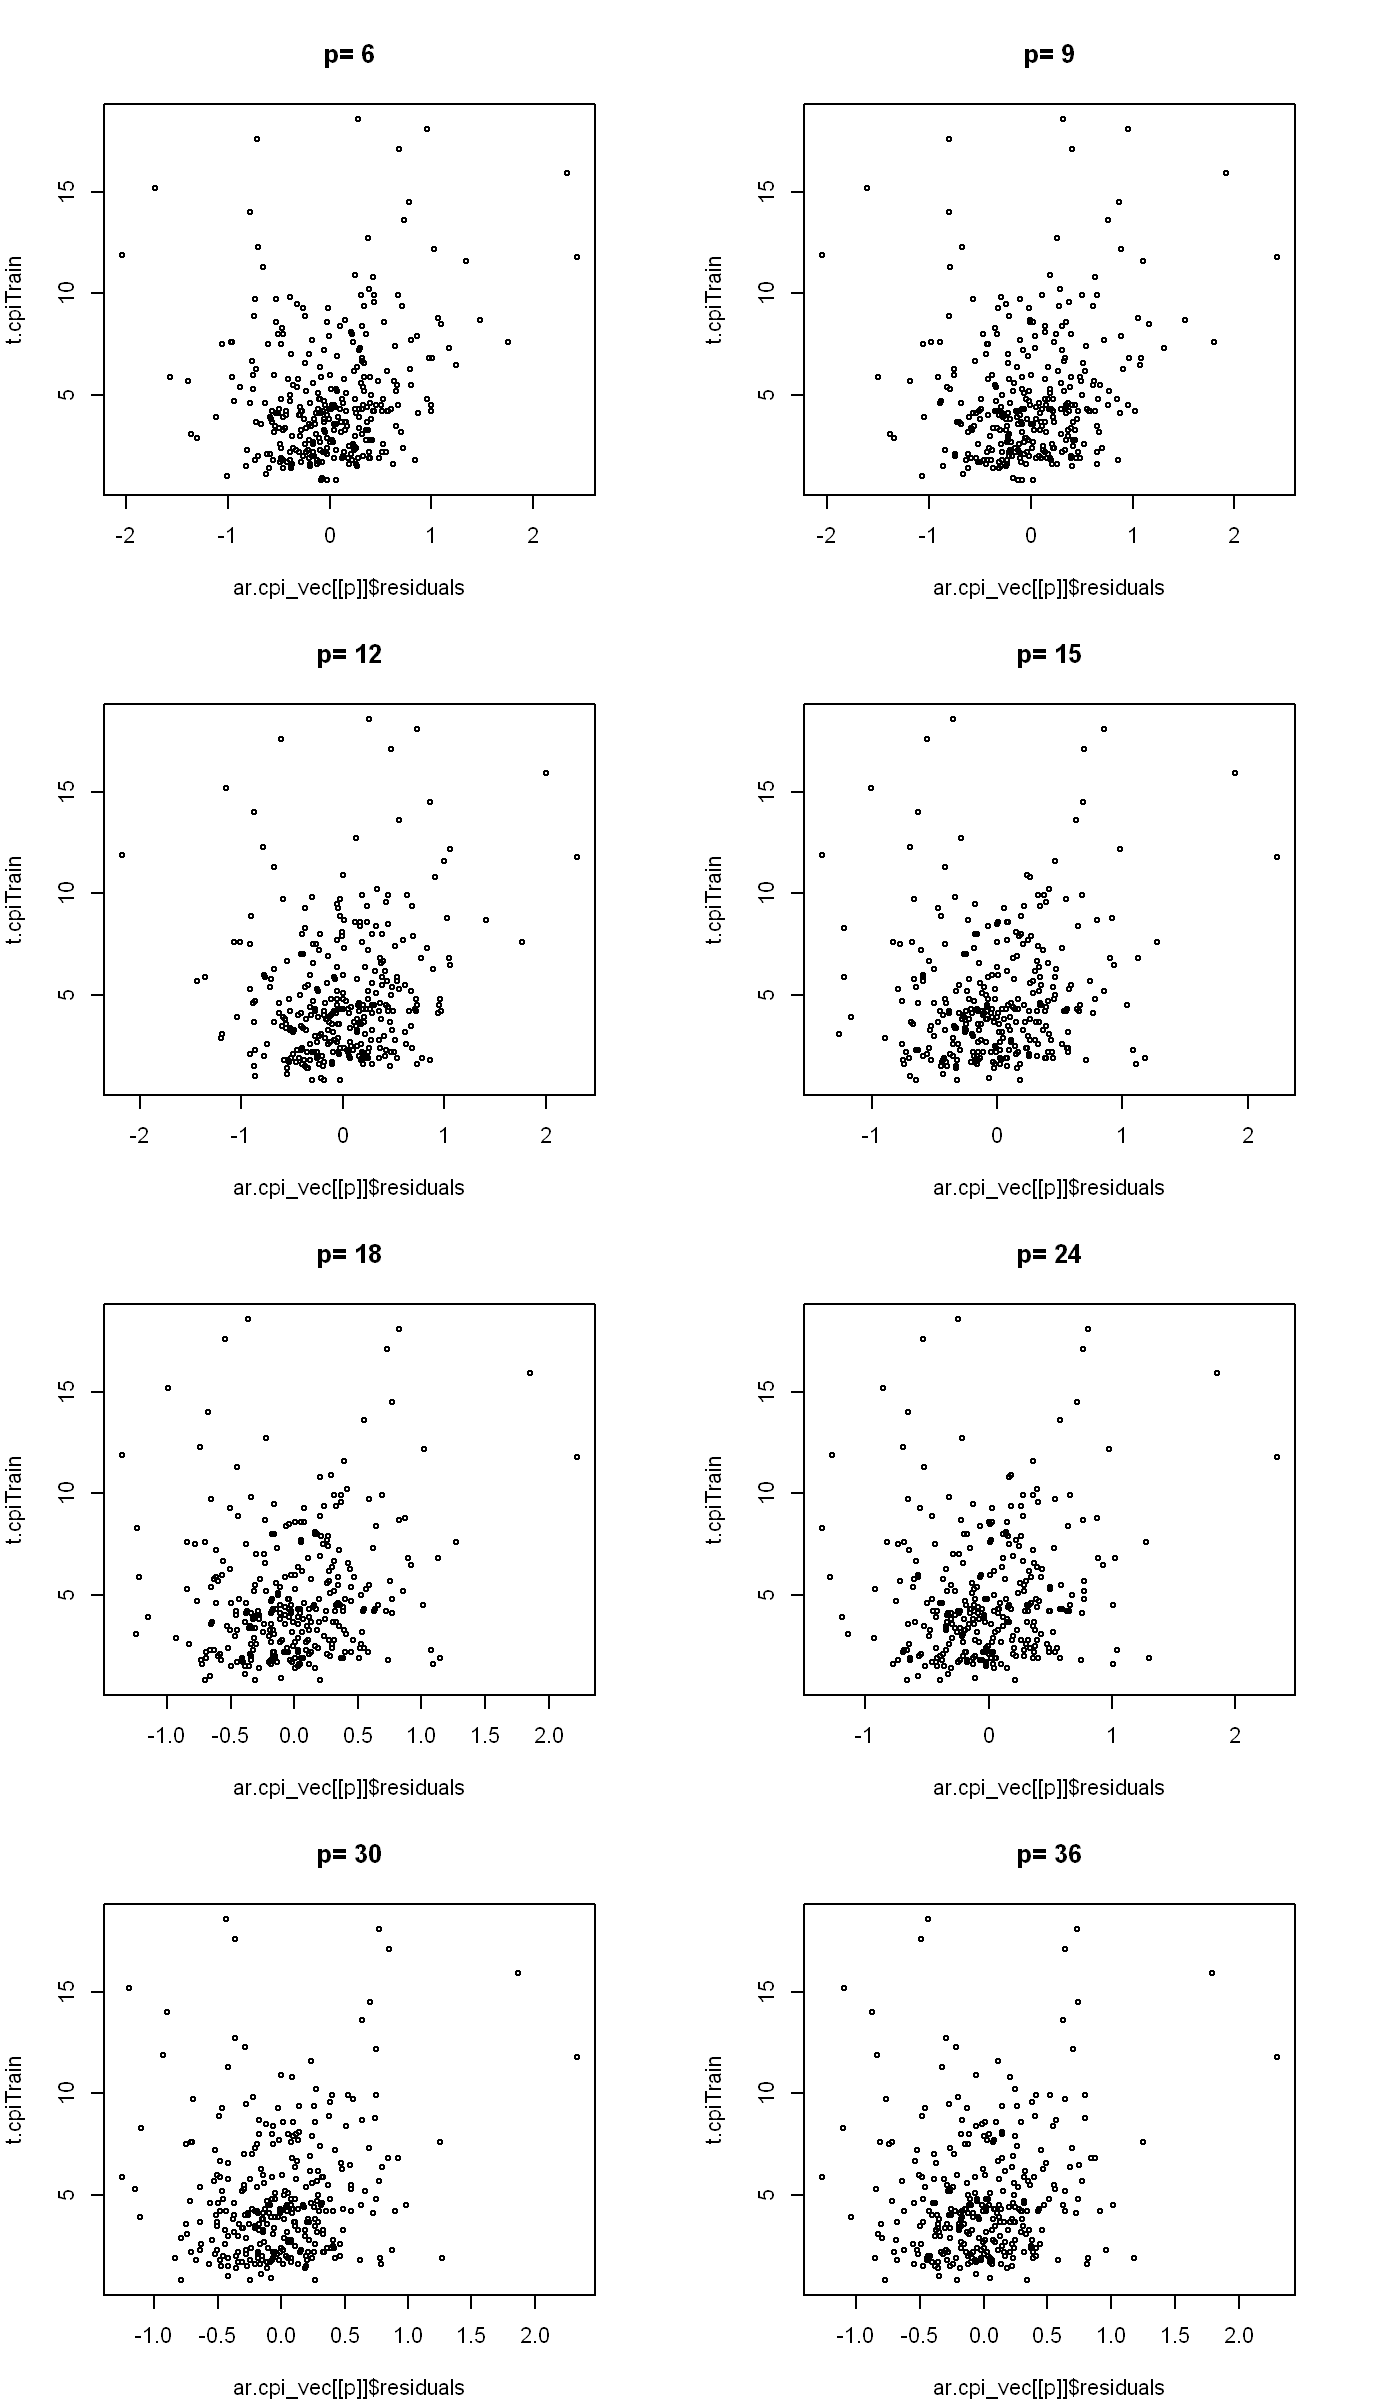

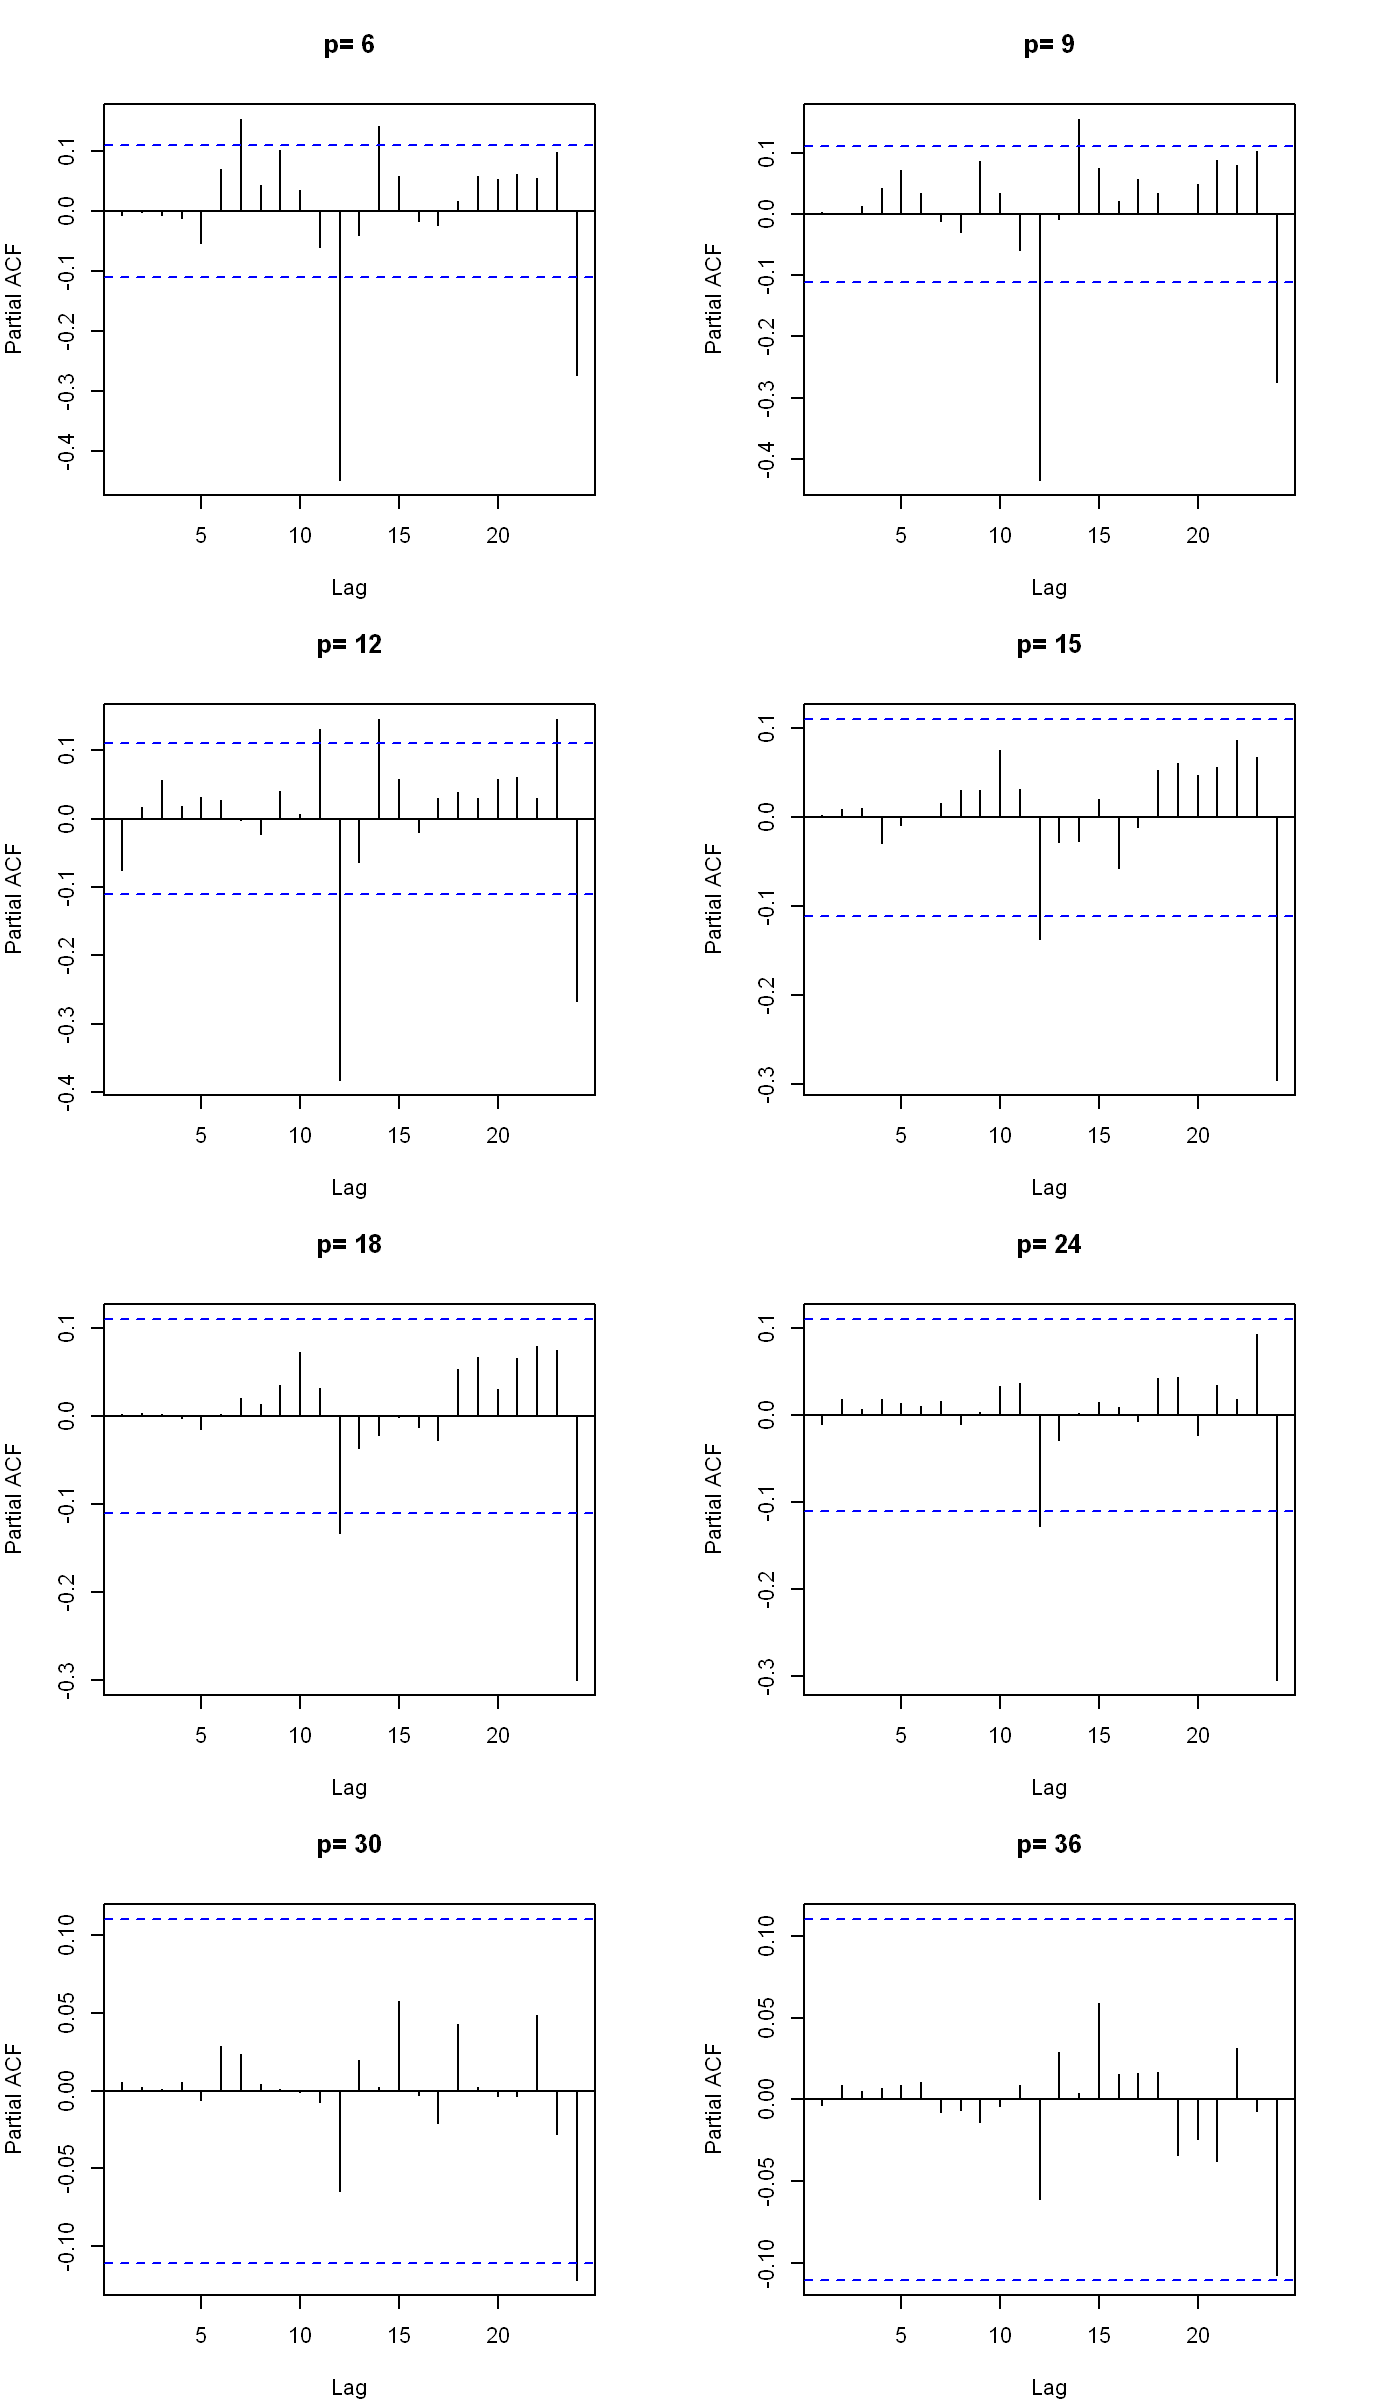

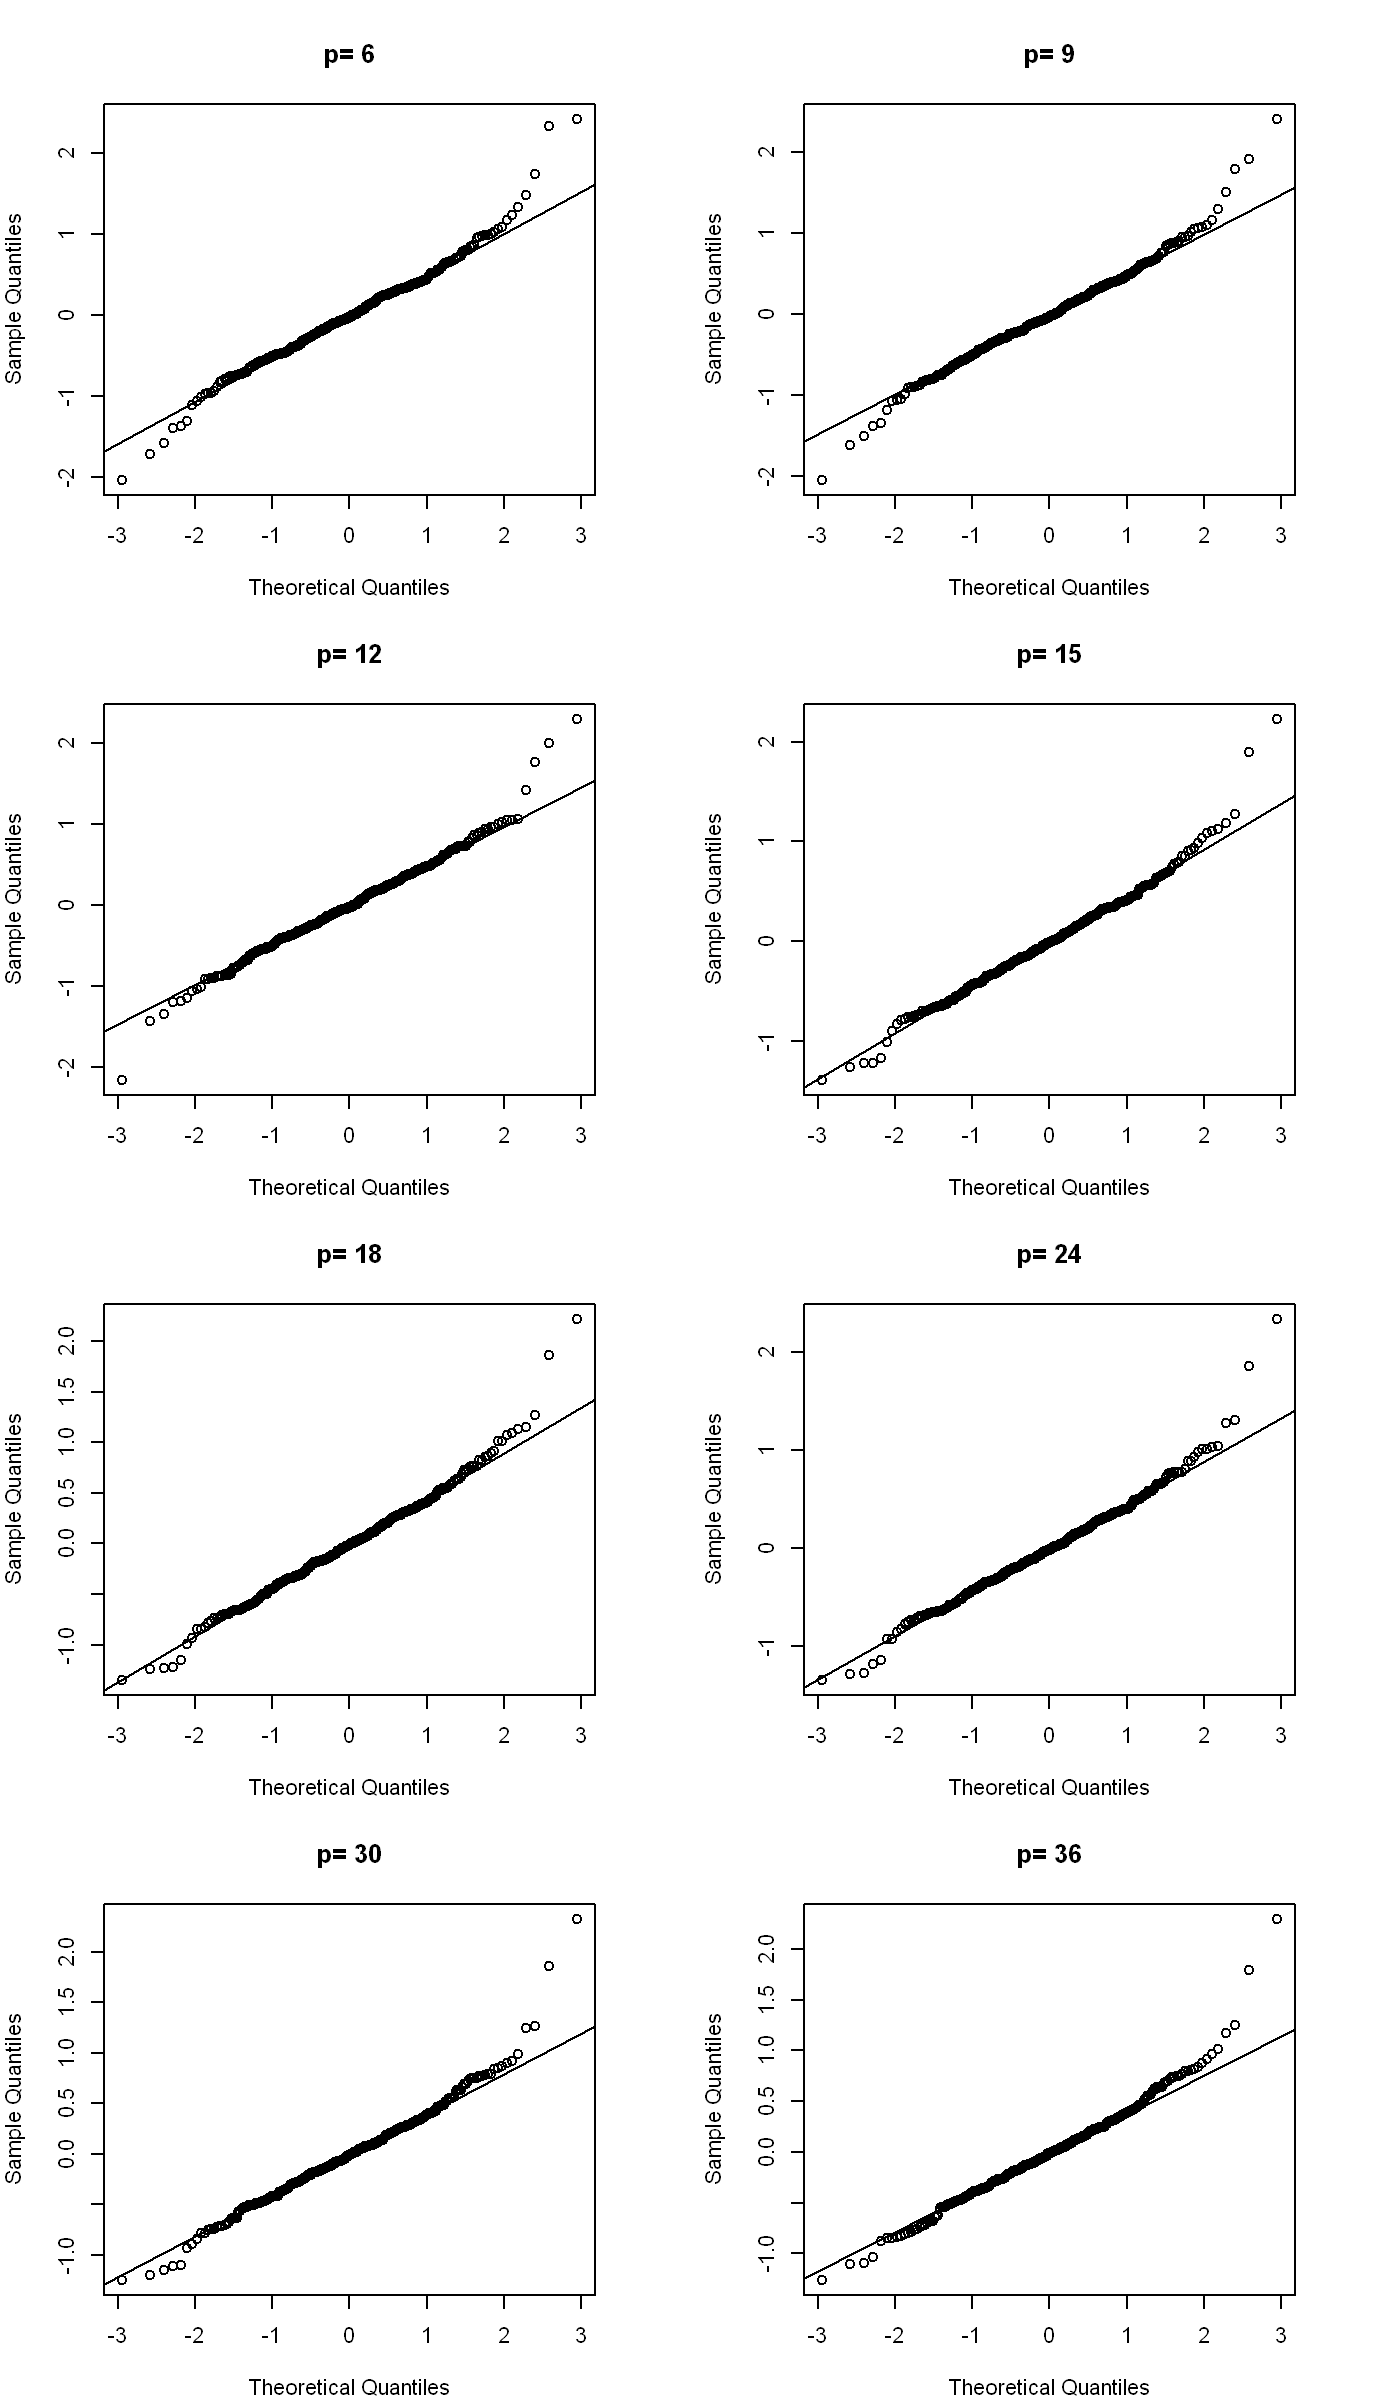

In [7]:
options(repr.plot.width = 7, repr.plot.height = 12, repr.plot.res = 200)

par(mfrow = c(round(n_est/2),2),mar=c(4,4,4,4))
for(p in 1:n_est)
{   
    plot(ar.cpi_vec[[p]]$residuals,t.cpiTrain,main=paste("p=",p_grid[p]))
    
}

par(mfrow = c(round(n_est/2),2),mar=c(4,4,4,4))

for(p in 1:n_est)
{   
    pacf(ar.cpi_vec[[p]]$residuals,main=paste("p=",p_grid[p]))
    
}

for(p in 1:n_est)
{   
    qqnorm(ar.cpi_vec[[p]]$residuals,main=paste("p=",p_grid[p]))
    qqline(ar.cpi_vec[[p]]$residuals)
    
}

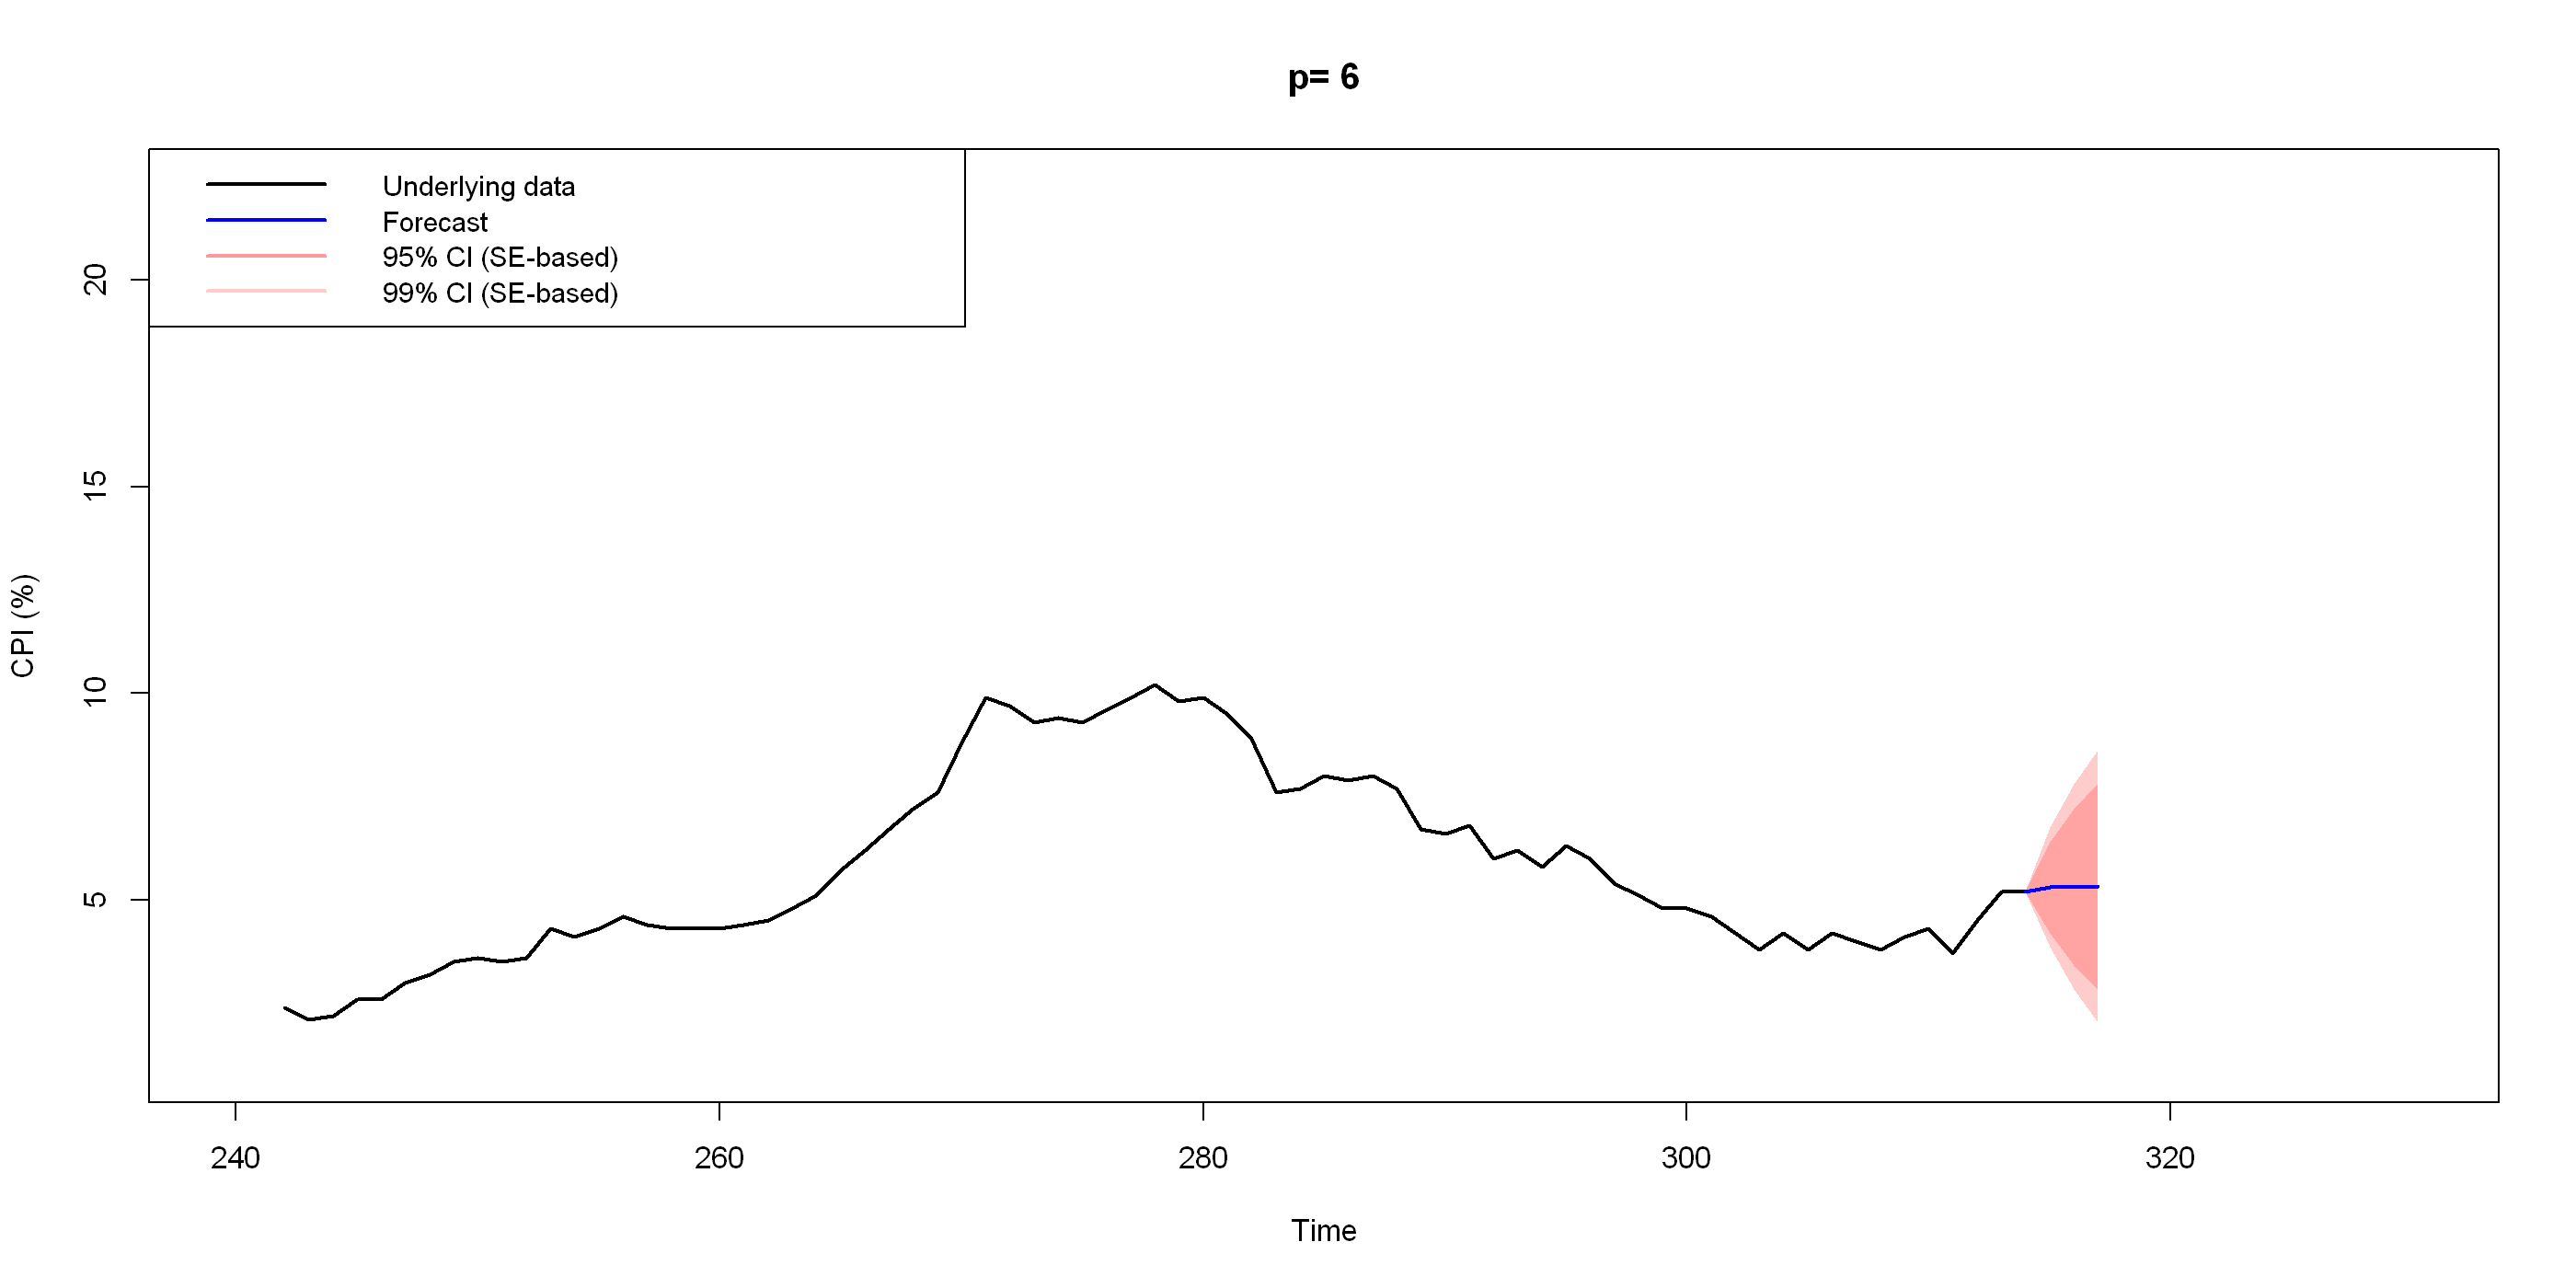

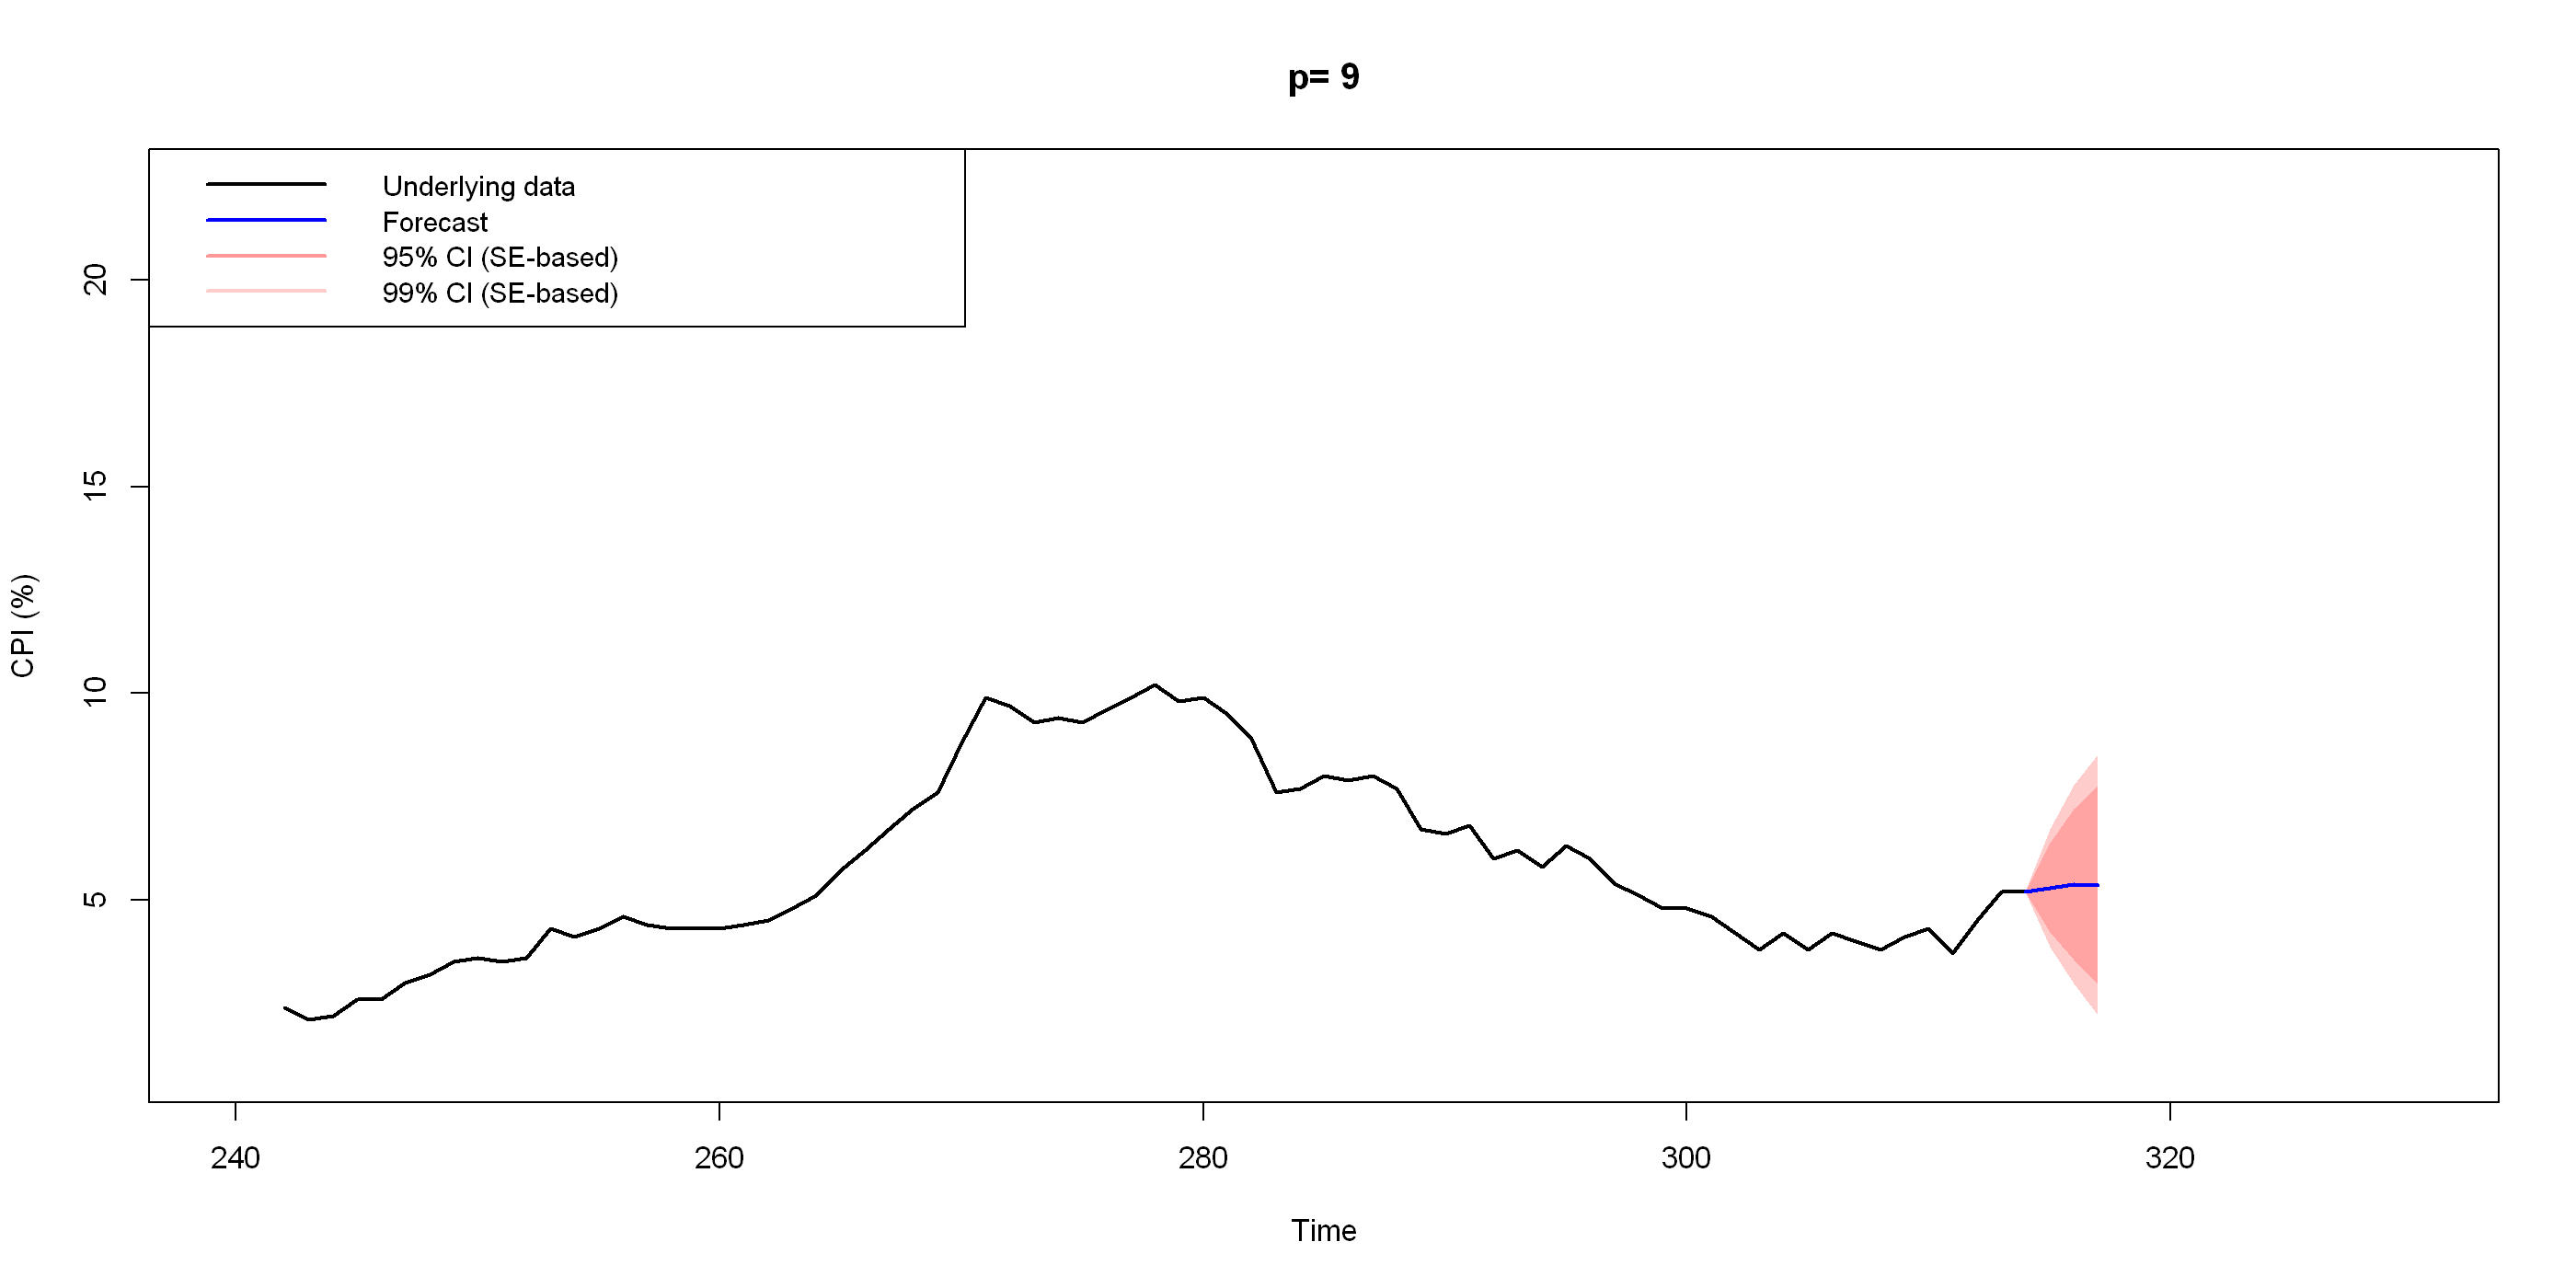

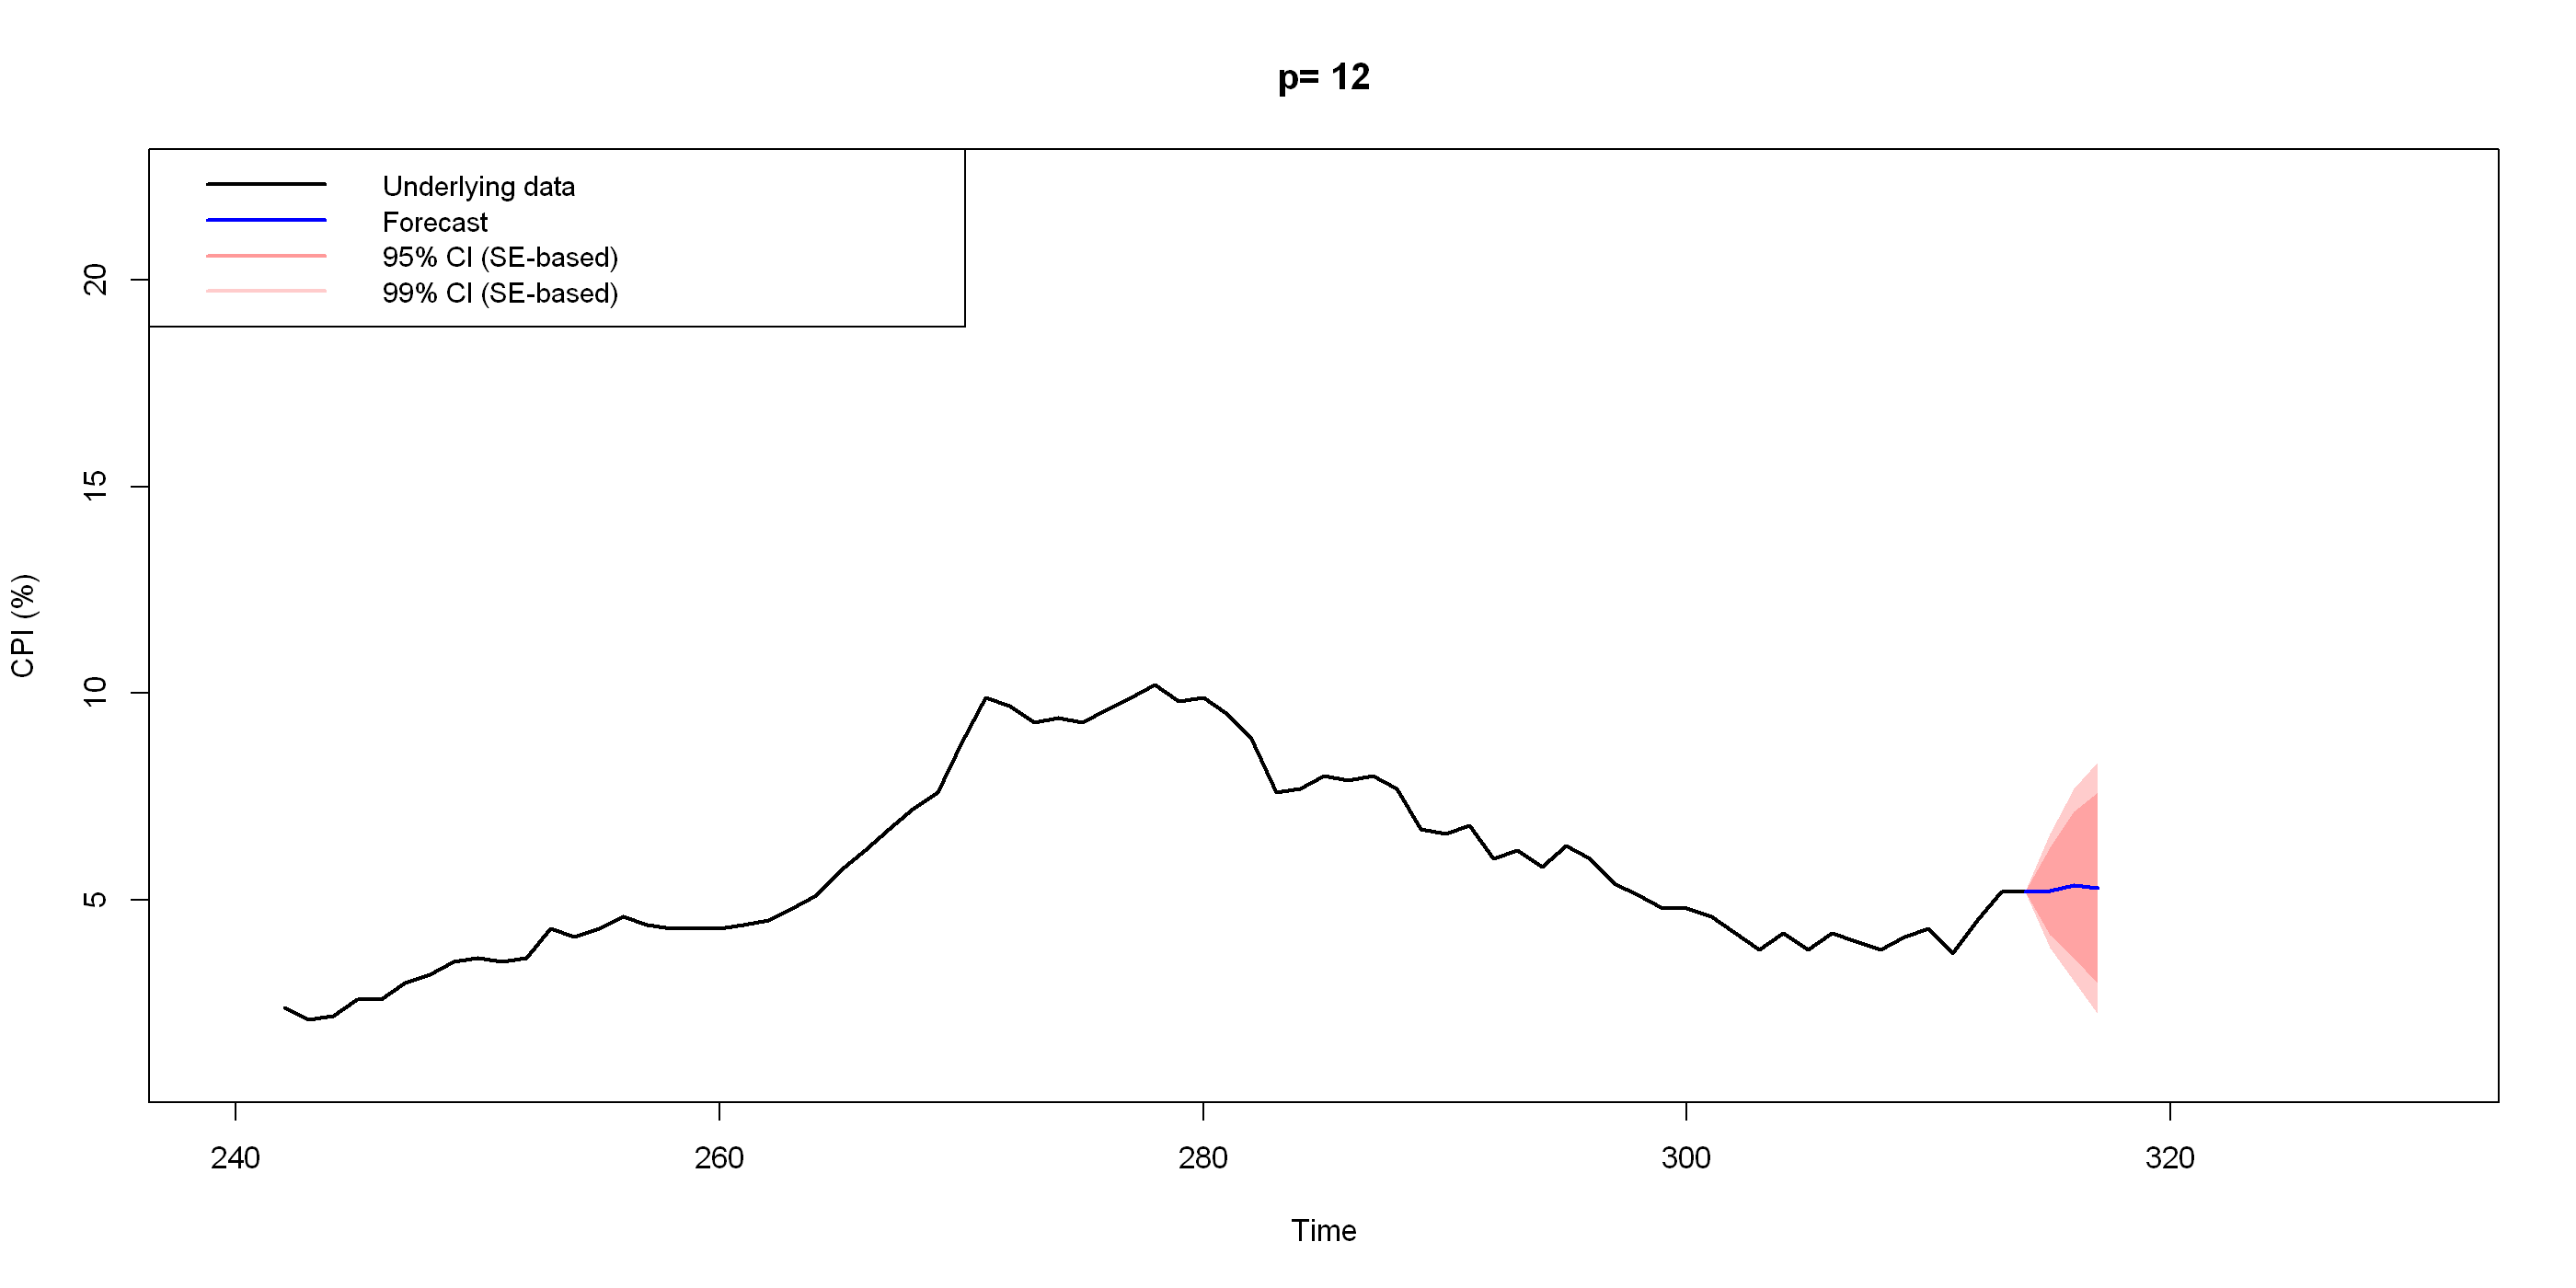

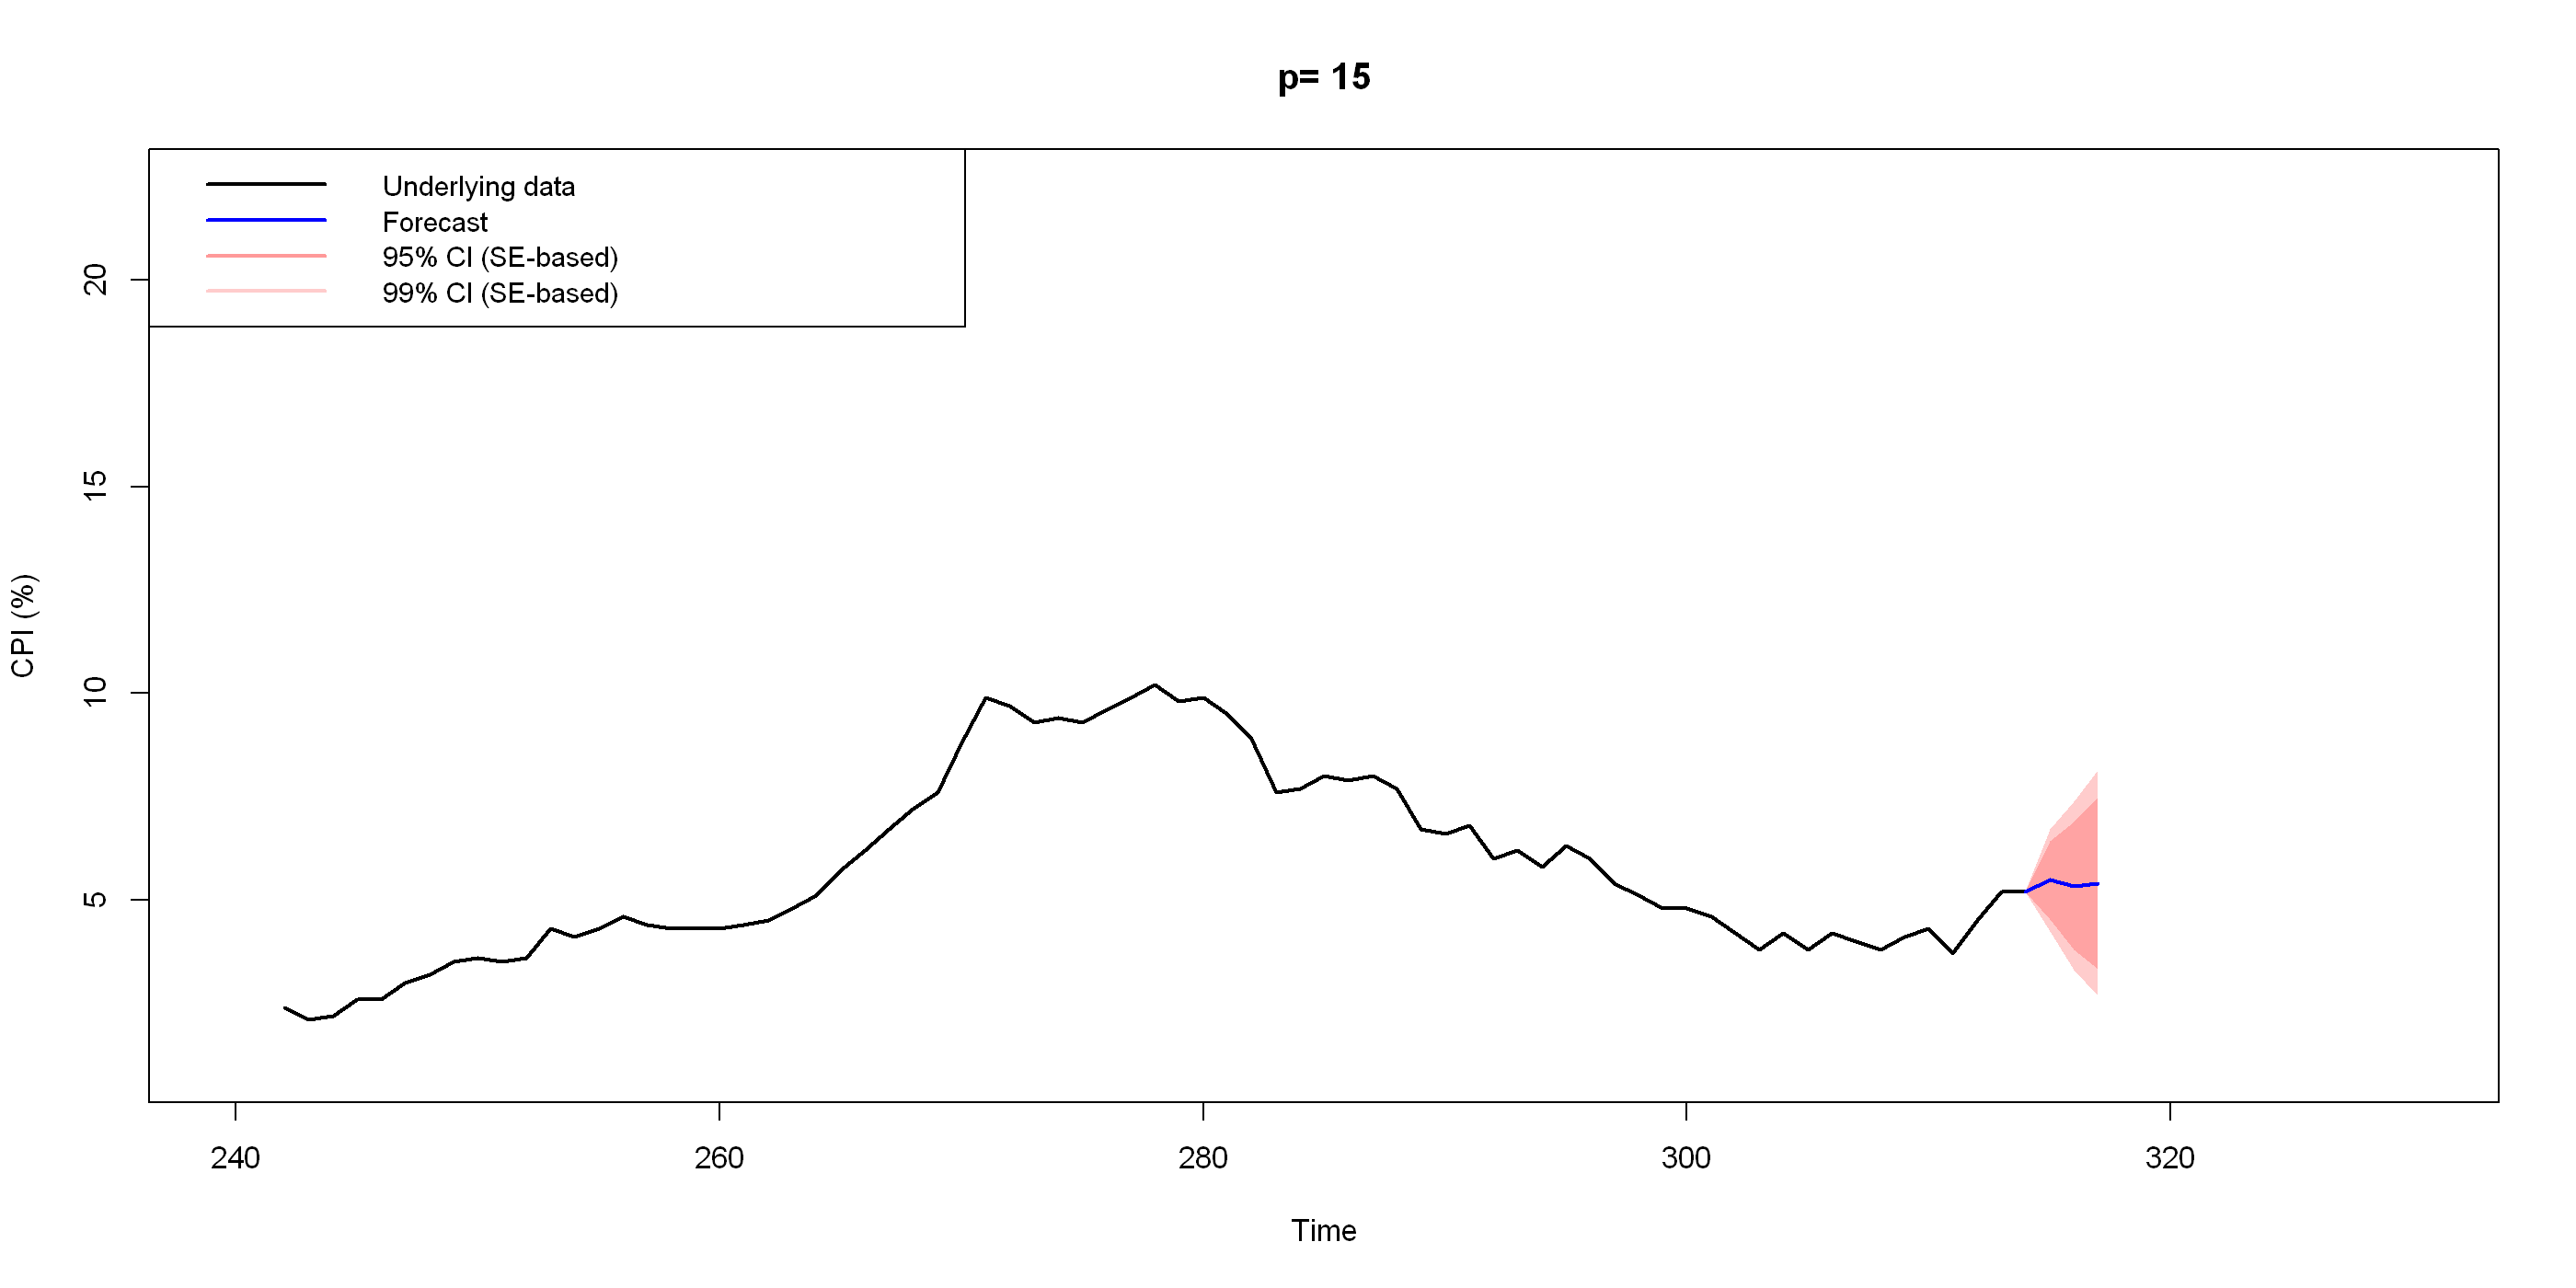

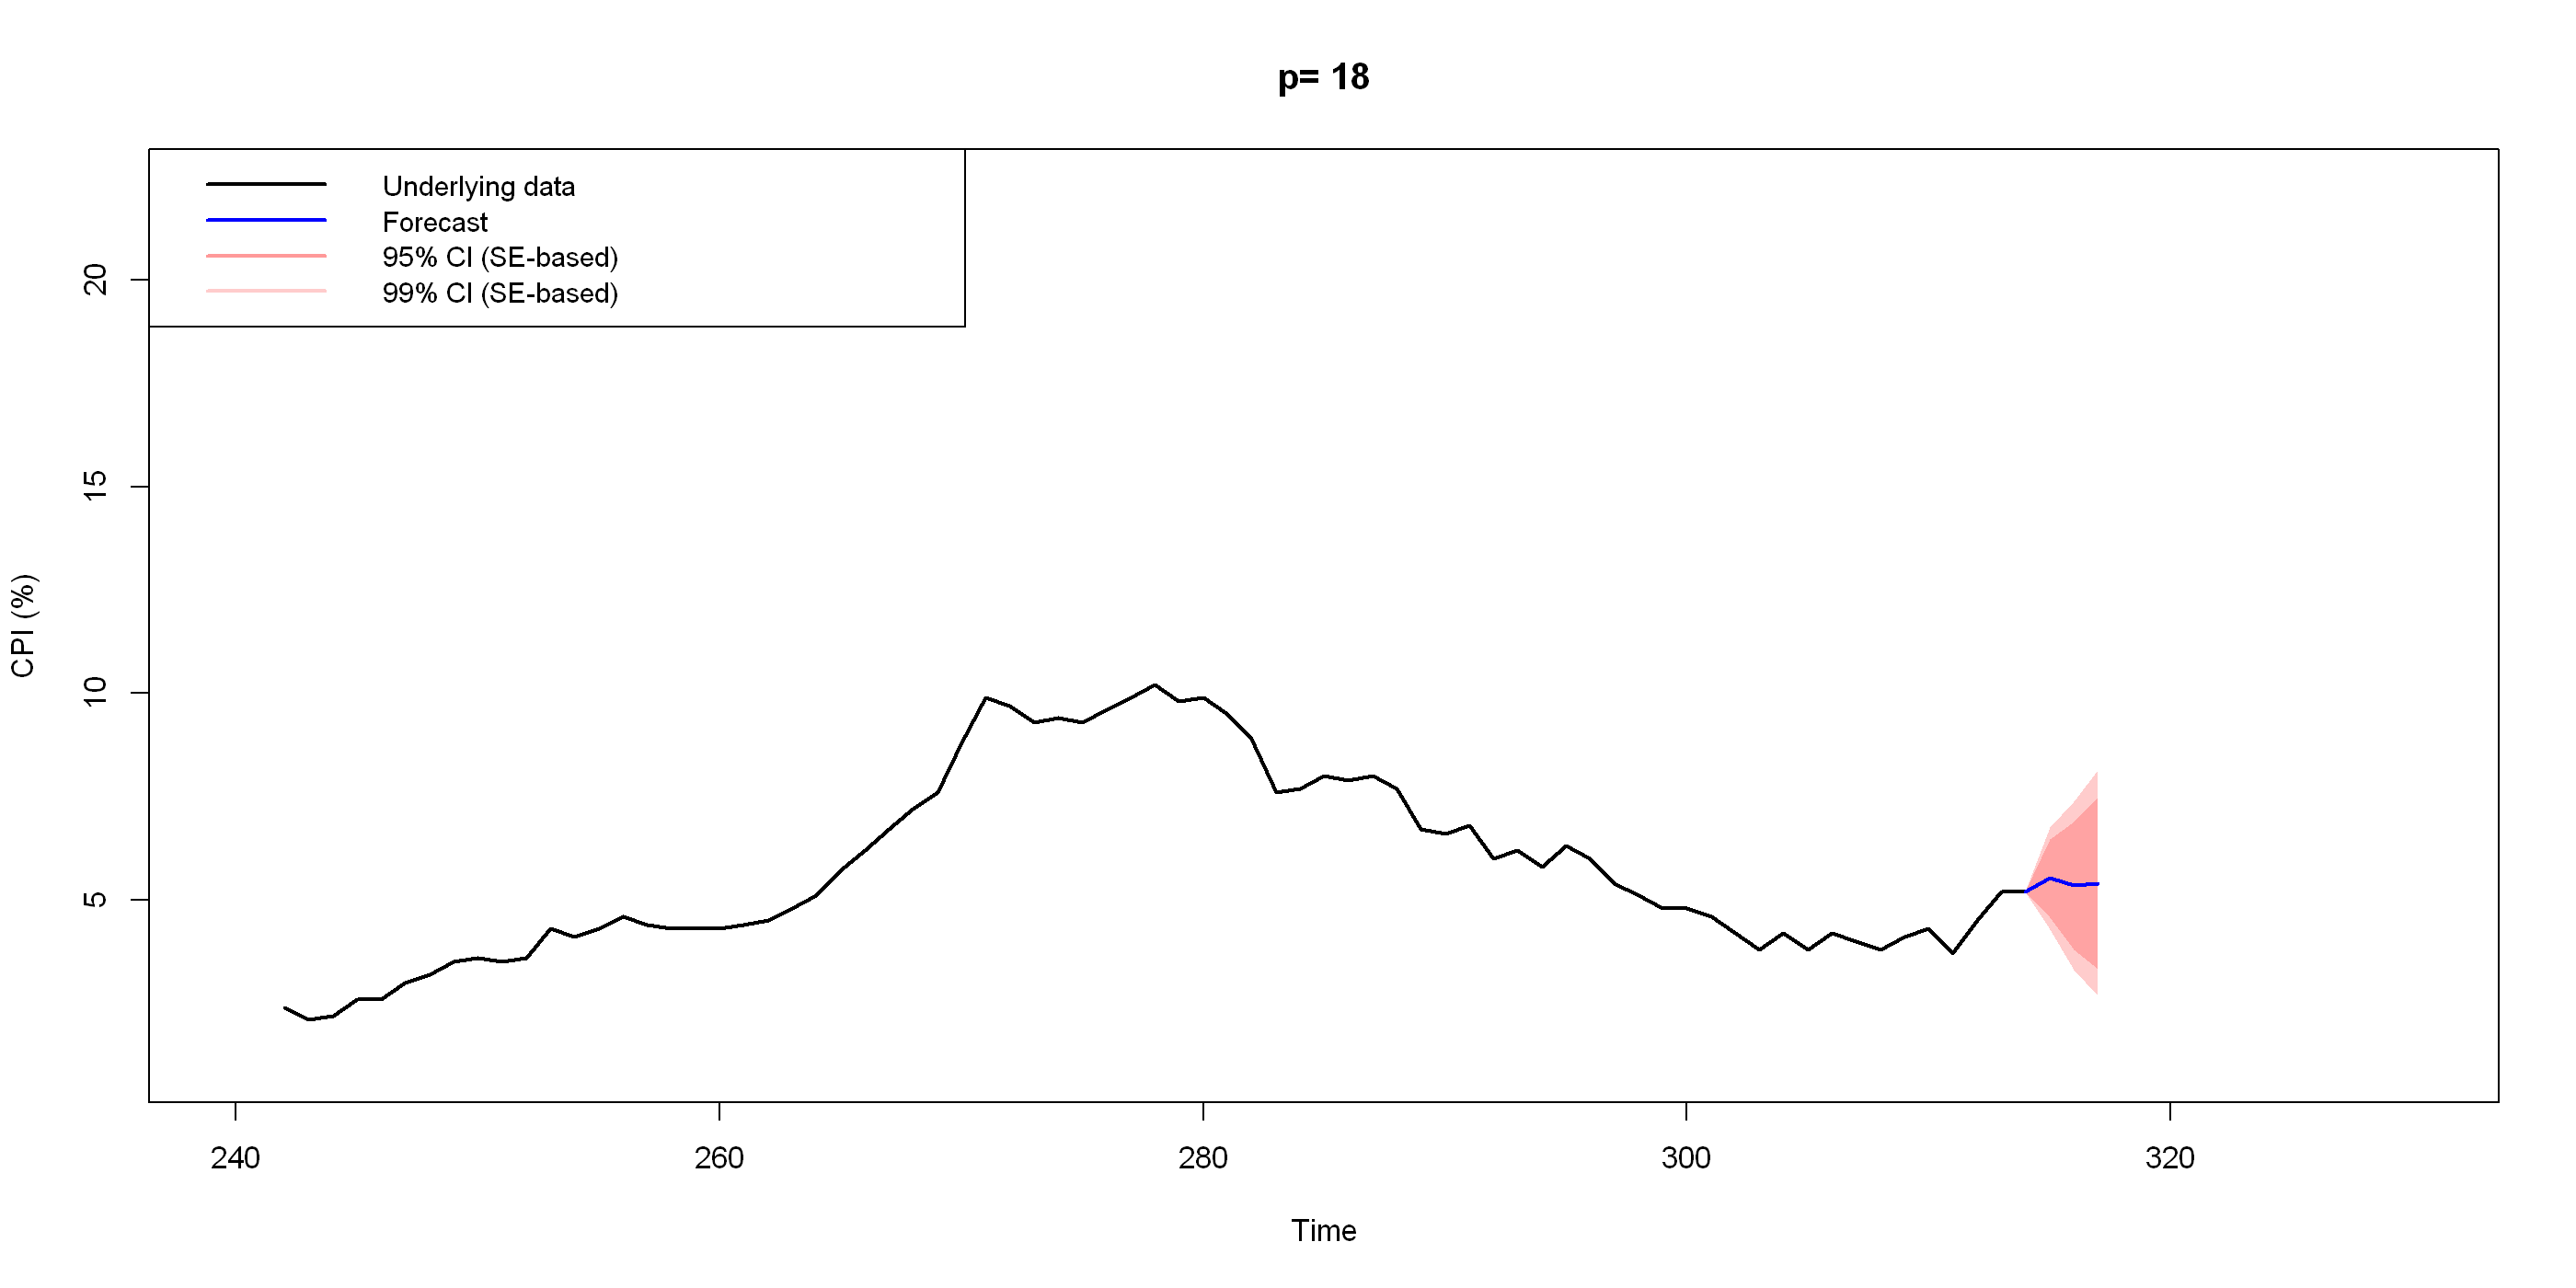

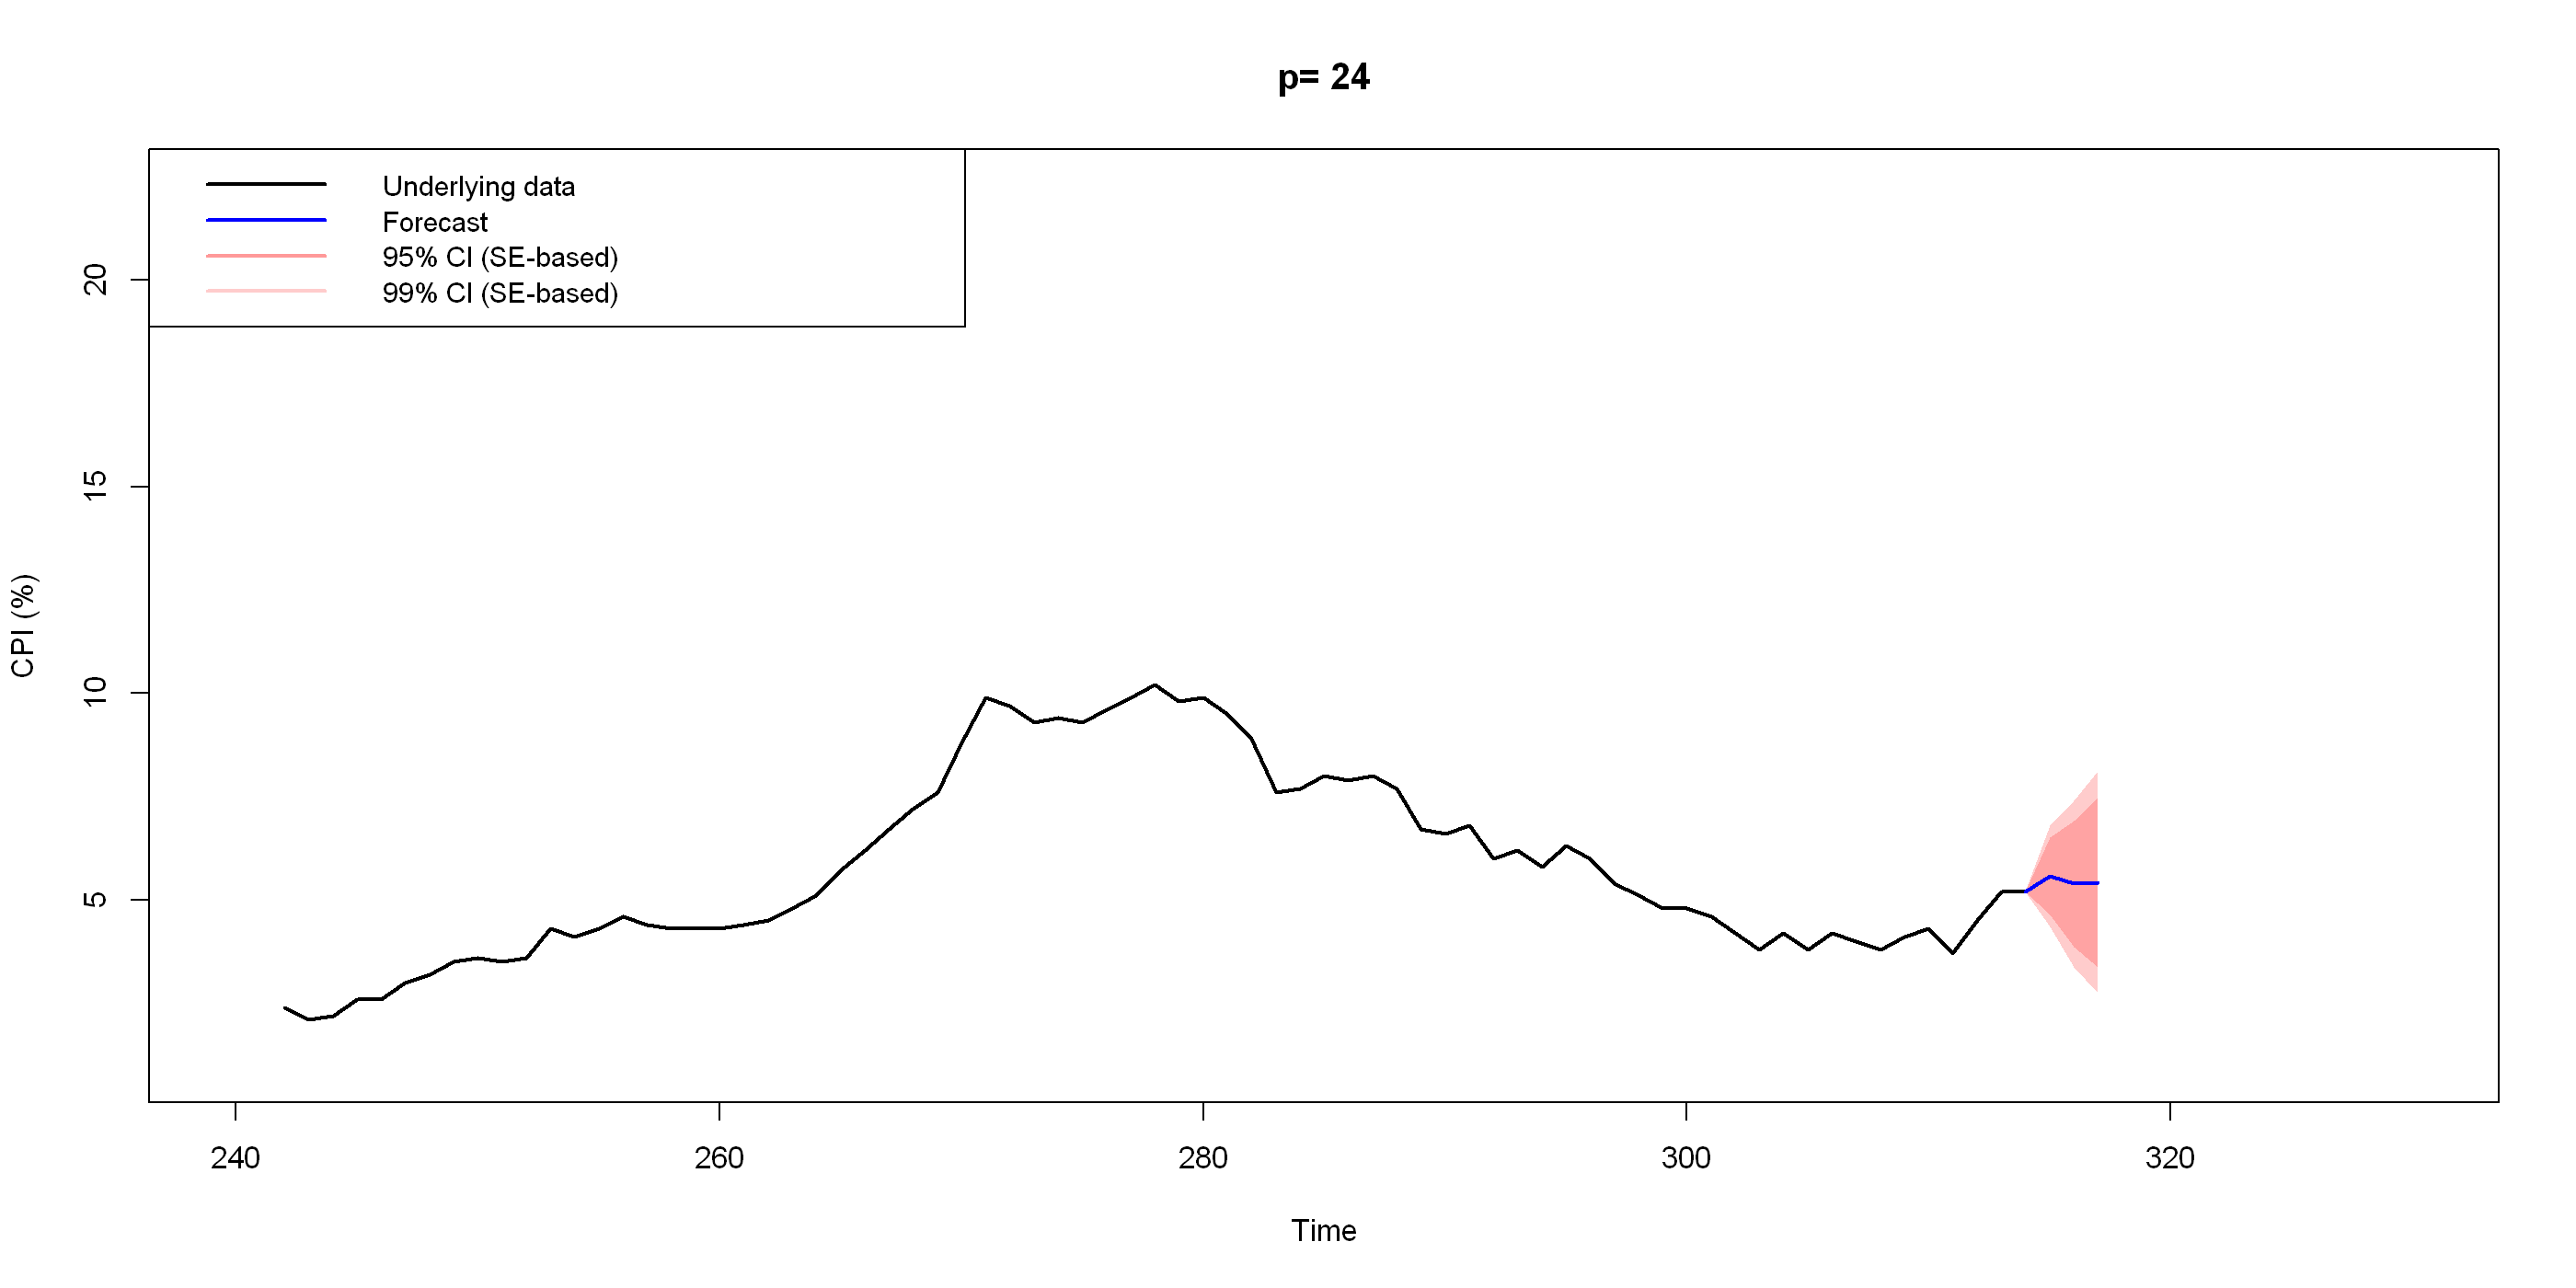

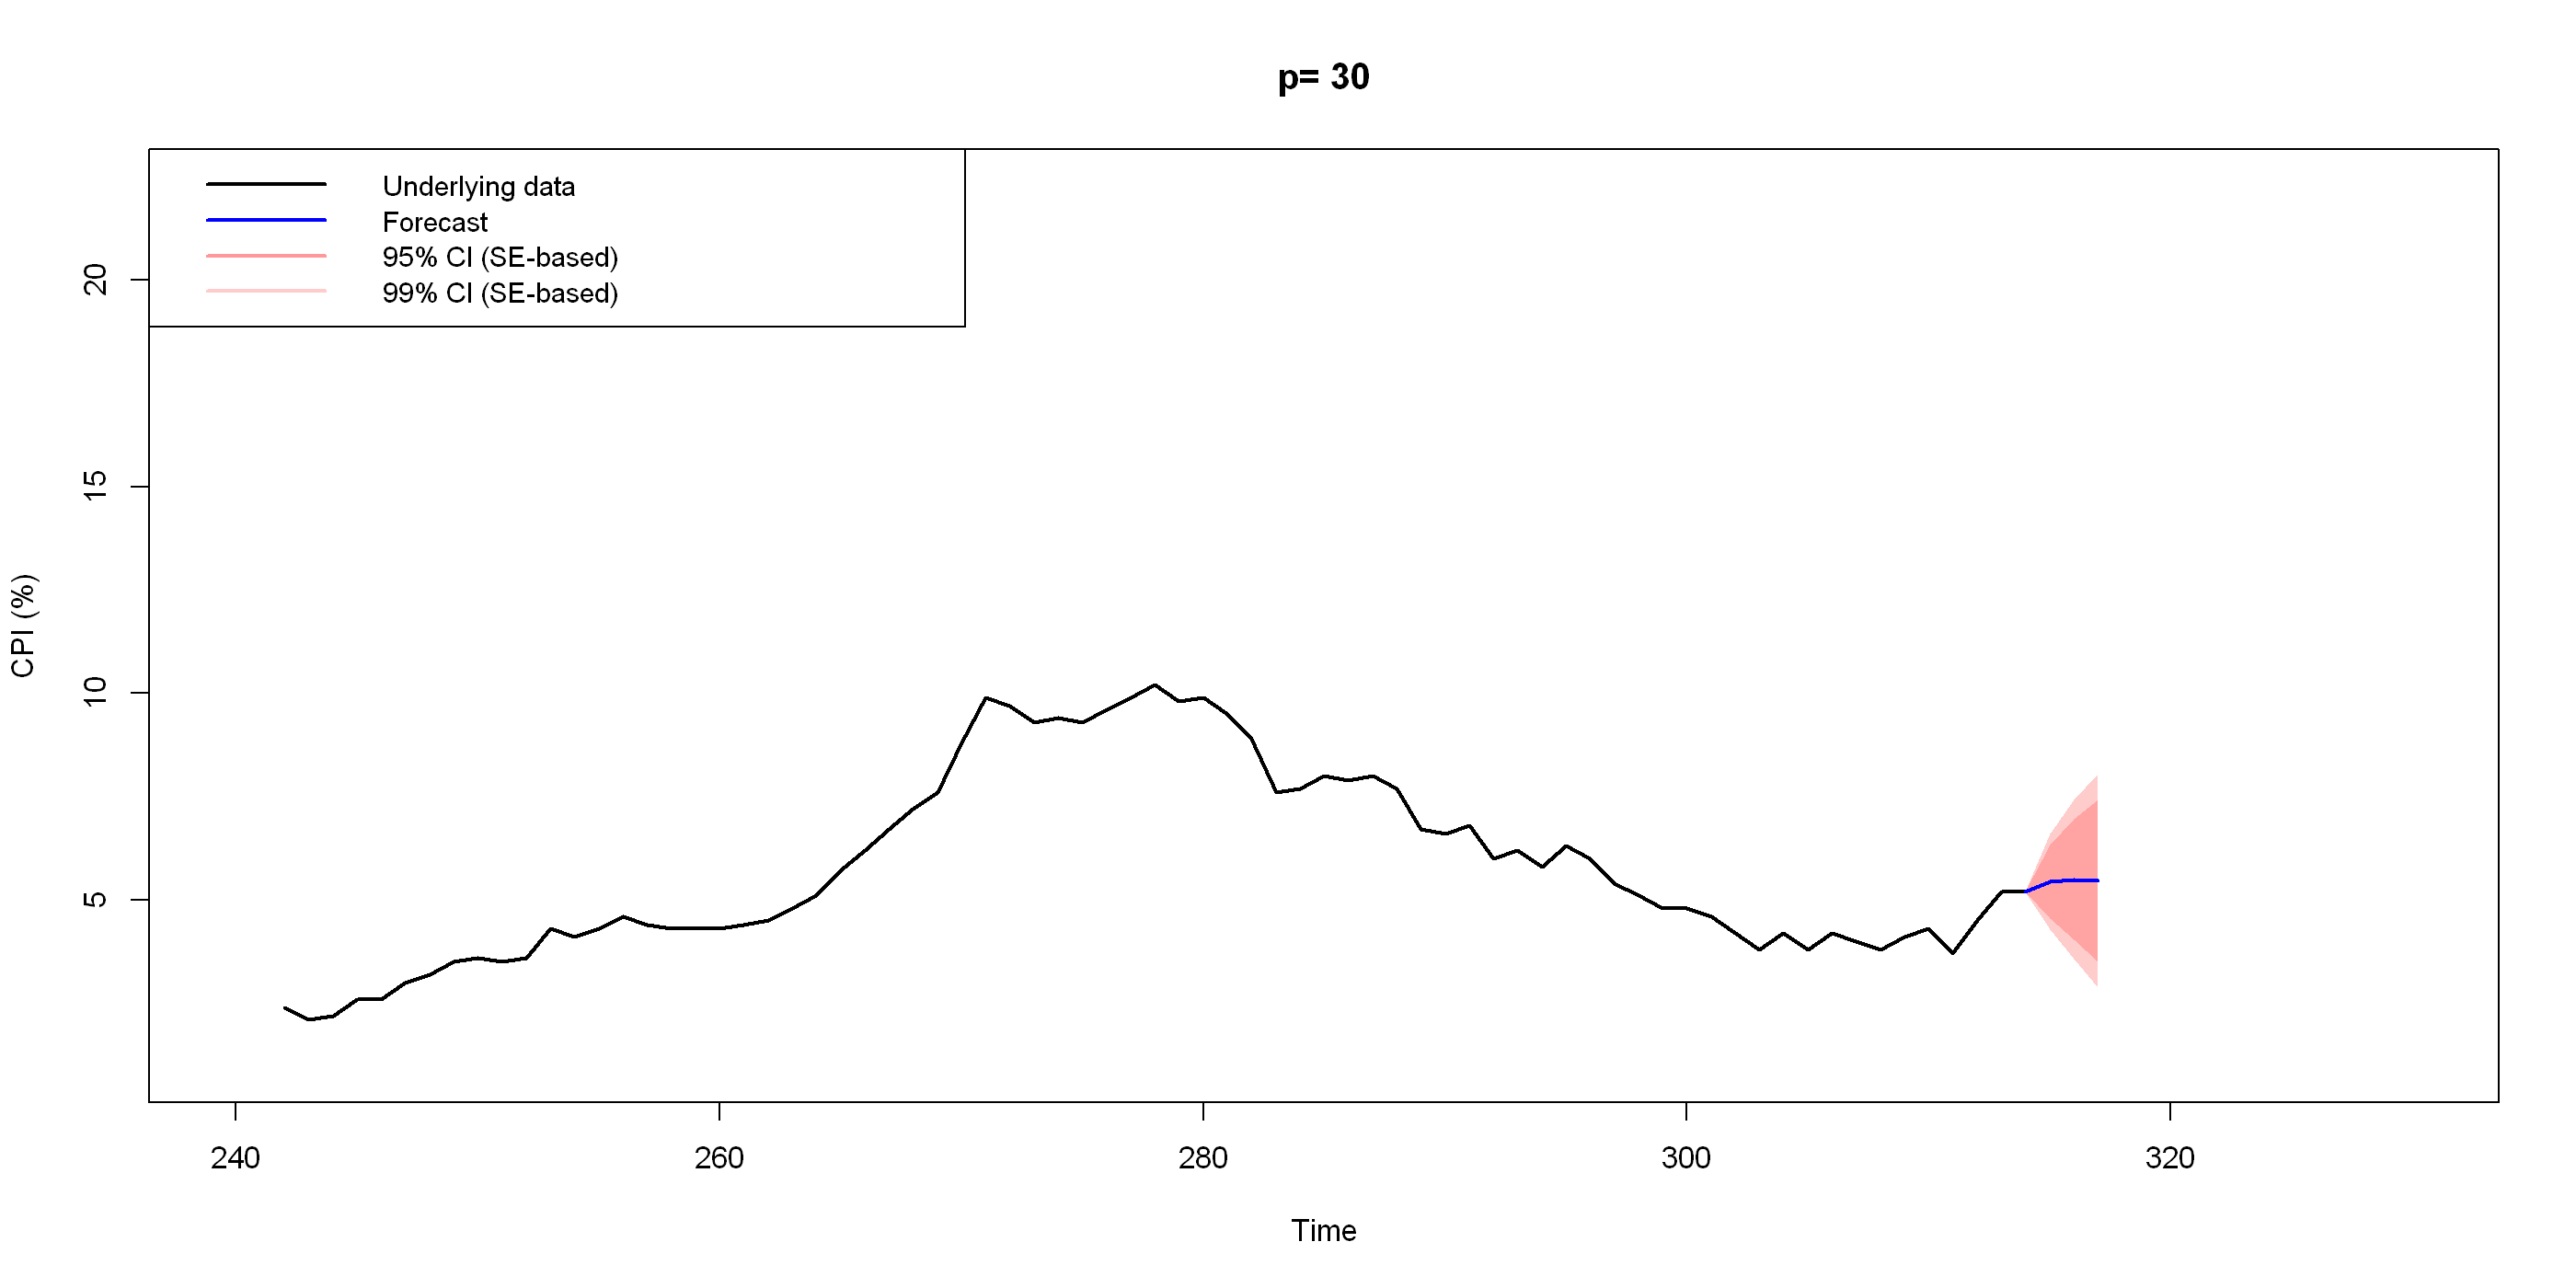

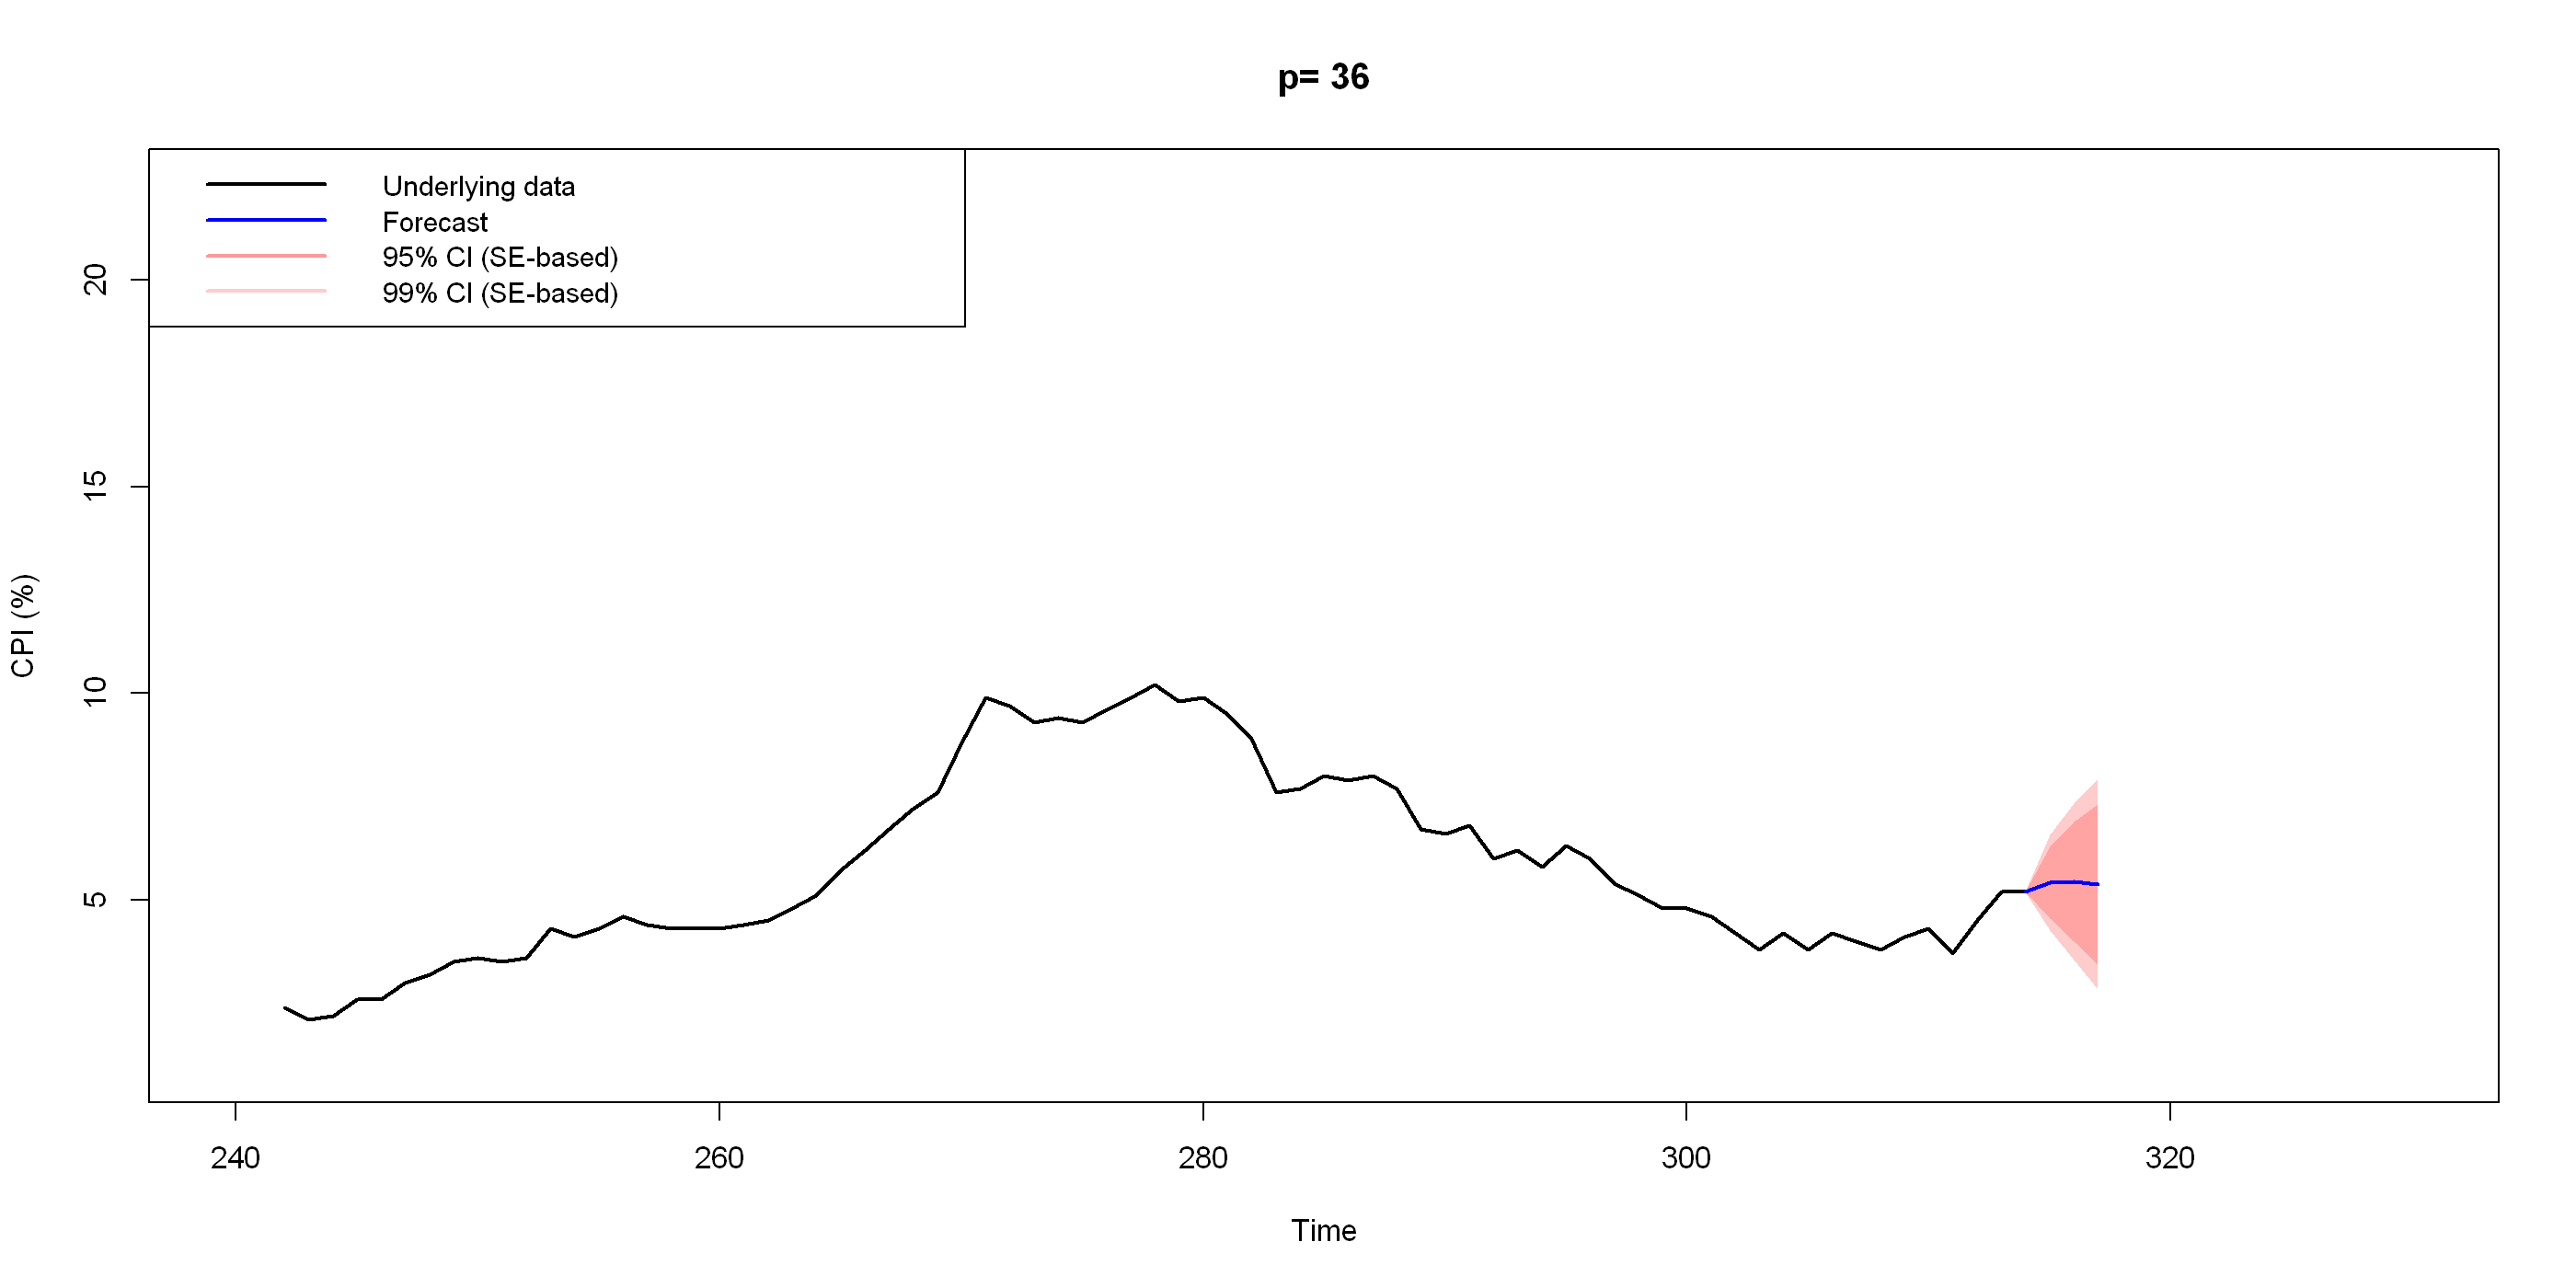

In [8]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

pred_vec <- vector(mode = "list",n_est)
se_vec <- vector(mode = "list",n_est)
for(p in 1:n_est)
{
    cpi.pred <- predict(ar.cpi_vec[[p]],n.ahead = 3)
    x_pred <- time(cpi.pred$pred)
    x_conn <- c(x_pred[1]-1, x_pred)
    y_conn <- c((t.cpi)[n_x-horizon], cpi.pred$pred)
    se_conn <- c(0,cpi.pred$se)

    pred_vec[[p]]<- y_conn
    se_vec[[p]]<-se_conn

    plot(window(t.cpi,start = n_x-max(5*horizon,72)),lw=2,xlim=c(240,330),ylim = c(1.2*min(t.cpi),1.2*max(t.cpi)),ylab="CPI (%)",main=paste("p=",p_grid[p]))
    polygon(c(x_conn,rev(x_conn)),c(y_conn+ z99 * se_conn, rev(y_conn - z99 * se_conn)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
    polygon(c(x_conn,rev(x_conn)),c(y_conn+ z95 * se_conn, rev(y_conn - z95 * se_conn)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
    lines(x_conn,y_conn,col = "blue",lw=2)
    lines(window(t.cpi,start = n_x-5*horizon),lw=2,ylim = c(1.2*min(t.cpi),1.2*max(t.cpi)),ylab="CPI (%)")

    legend("topleft",cex=0.9,legend = c("Underlying data","Forecast","95% CI (SE-based)","99% CI (SE-based)"),col=c("black","blue",col=adjustcolor("red",alpha.f = 0.4),col=adjustcolor("red",alpha.f = 0.2)),lty = c(1,1,1,1),lw=c(2,2,2))
}

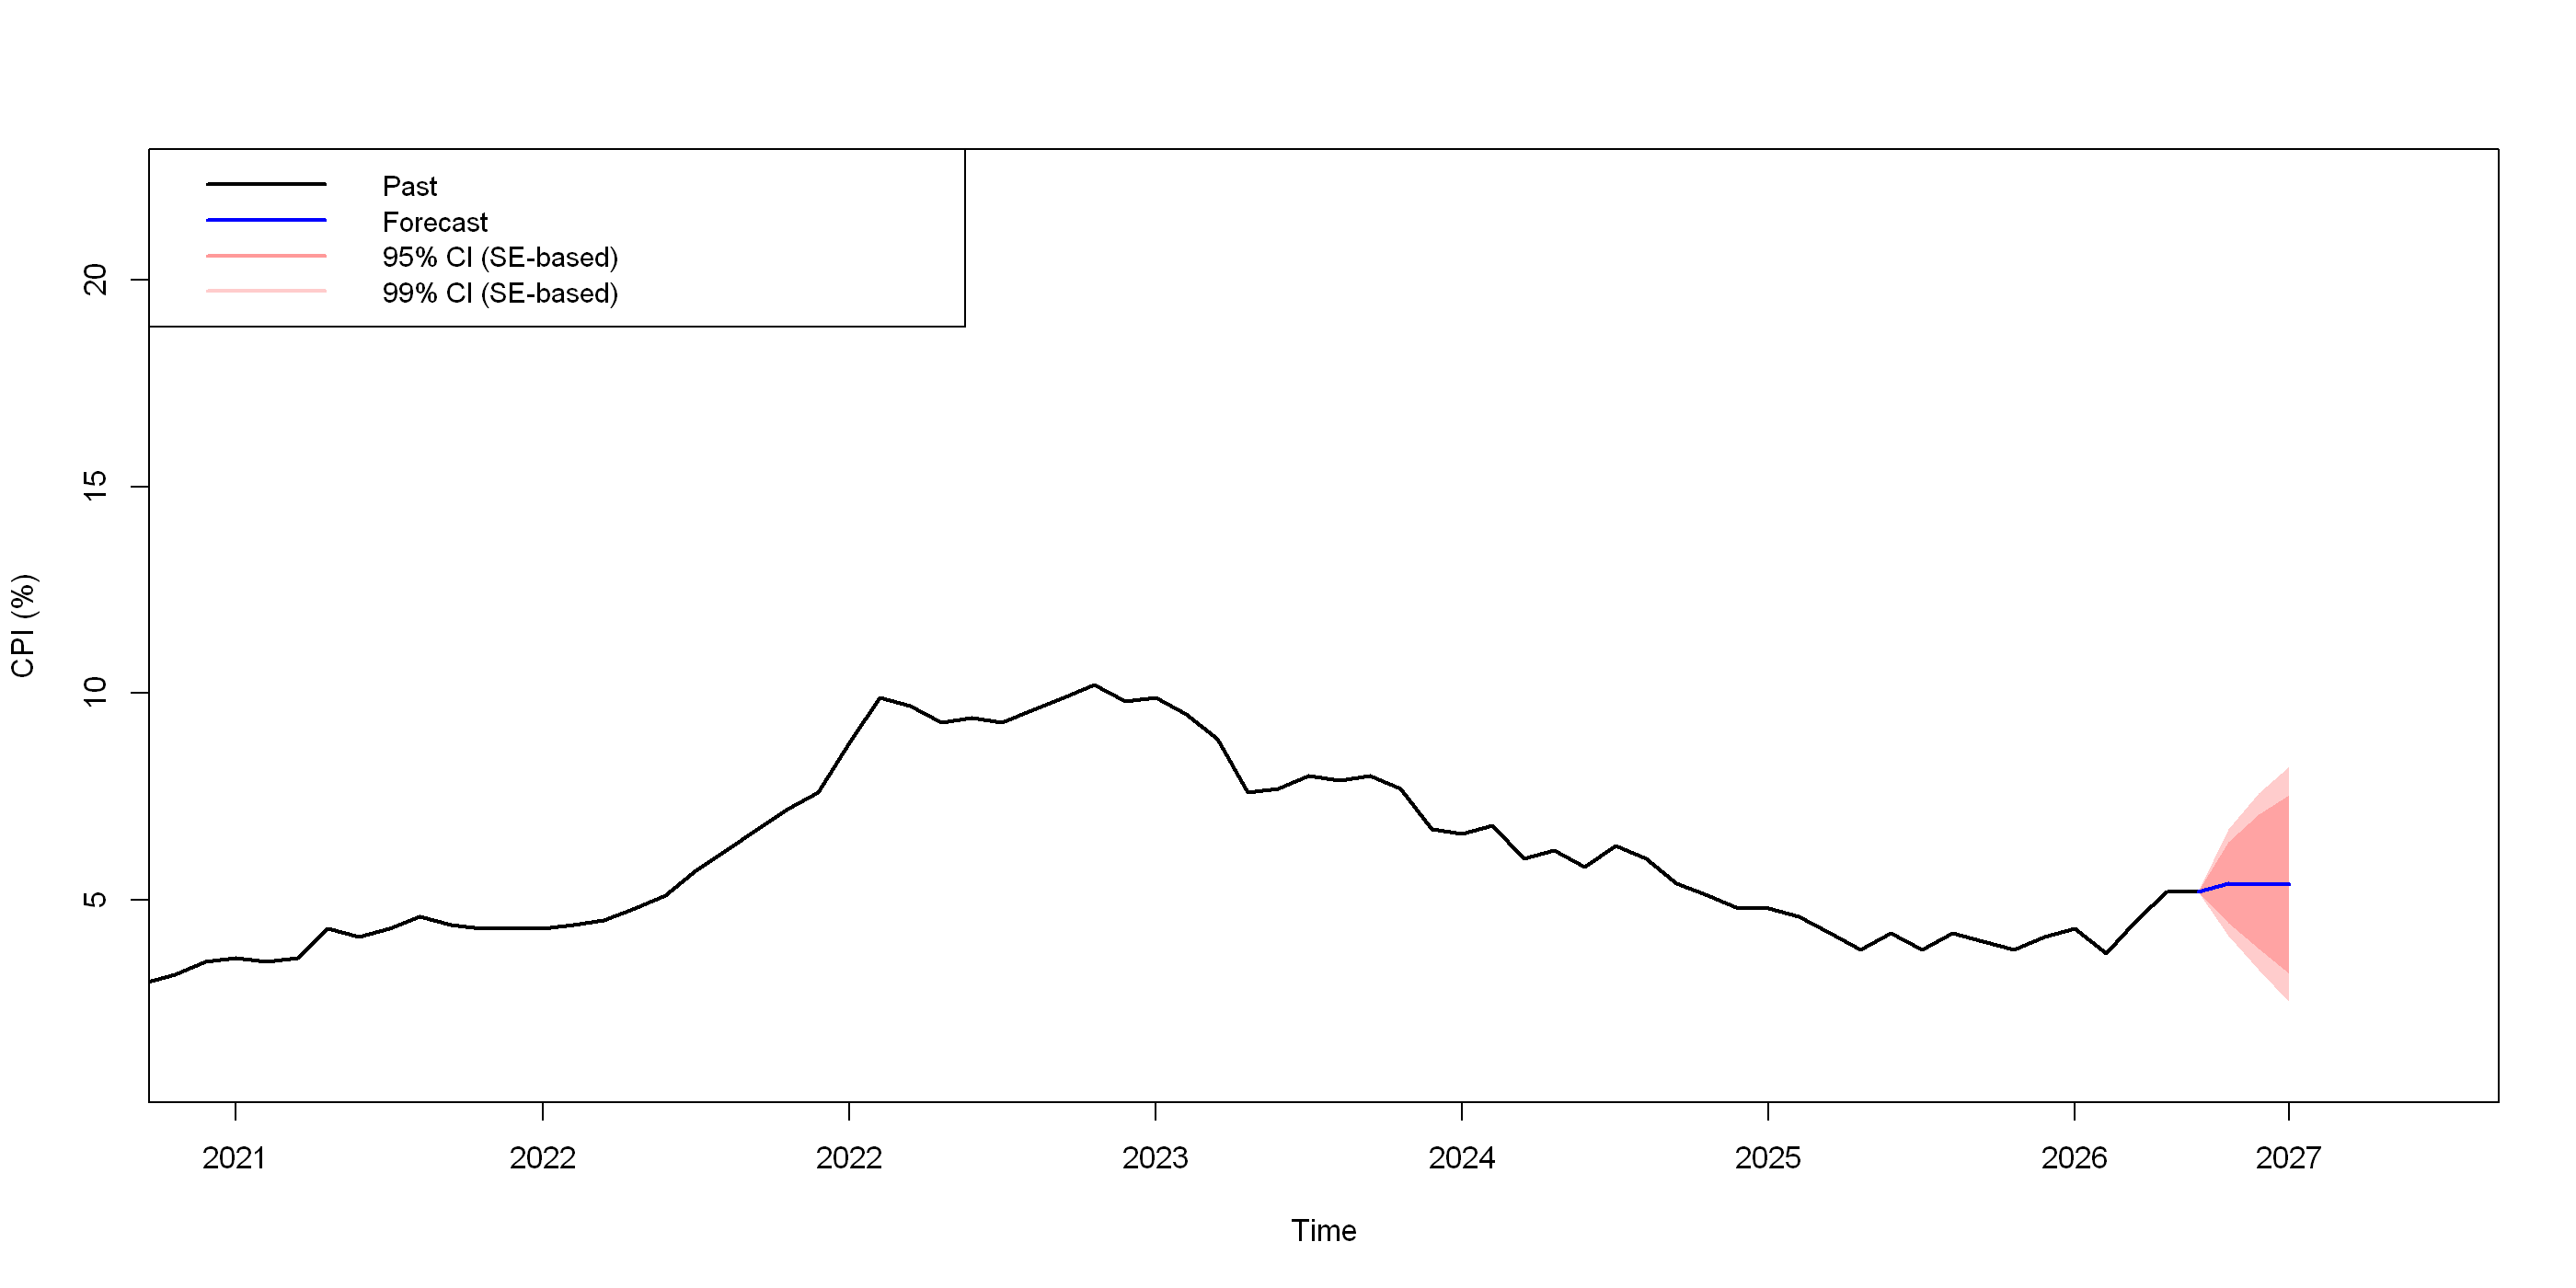

In [11]:
mean_pred <- Reduce("+", pred_vec) / length(pred_vec)
se_pred <- Reduce("+", se_vec) / length(se_vec)

t_actual <- time(dd[,2])
n_total <- length(t_actual)

dt <- t_actual[2] - t_actual[1]
t_forecast <- seq(t_actual[n_total] + dt, by = dt, length.out = horizon)
t_all <- c(t_actual, t_forecast)

plot(window(t.cpi,start = n_x-250),lw=2,xlim=c(250,321),ylim = c(1.2*min(t.cpi),1.2*max(t.cpi)),ylab="CPI (%)",xaxt = "n")
tick_pos <- c(seq(250, 310, by = 10), max(x_conn))
tick_labels <- c(format(t_all[seq(250, 310, by = 10)], digits = 4), "2027")
axis(1, at = tick_pos, labels = tick_labels)



polygon(c(x_conn,rev(x_conn)),c(y_conn+ z99 * se_pred, rev(y_conn - z99 * se_pred)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
polygon(c(x_conn,rev(x_conn)),c(y_conn+ z95 * se_pred, rev(y_conn - z95 * se_pred)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
lines(x_conn,mean_pred,col = "blue",lw=2)
lines(window(t.cpi,start = n_x-5*horizon),lw=2,ylim = c(1.2*min(t.cpi),1.2*max(t.cpi)),ylab="CPI (%)")
legend("topleft",cex=0.9,legend = c("Past","Forecast","95% CI (SE-based)","99% CI (SE-based)"),col=c("black","blue",col=adjustcolor("red",alpha.f = 0.4),col=adjustcolor("red",alpha.f = 0.2)),lty = c(1,1,1,1),lw=c(2,2,2))



In [12]:
for(ith in 2:6)
{
print((c(mean_pred[ith]-z90 * se_pred[ith],mean_pred[ith],mean_pred[ith]+z90 * se_pred[ith])))
}

[1] 4.585277 5.404103 6.222928
[1] 4.014711 5.381185 6.747659
[1] 3.563683 5.380515 7.197347
[1] NA NA NA
[1] NA NA NA


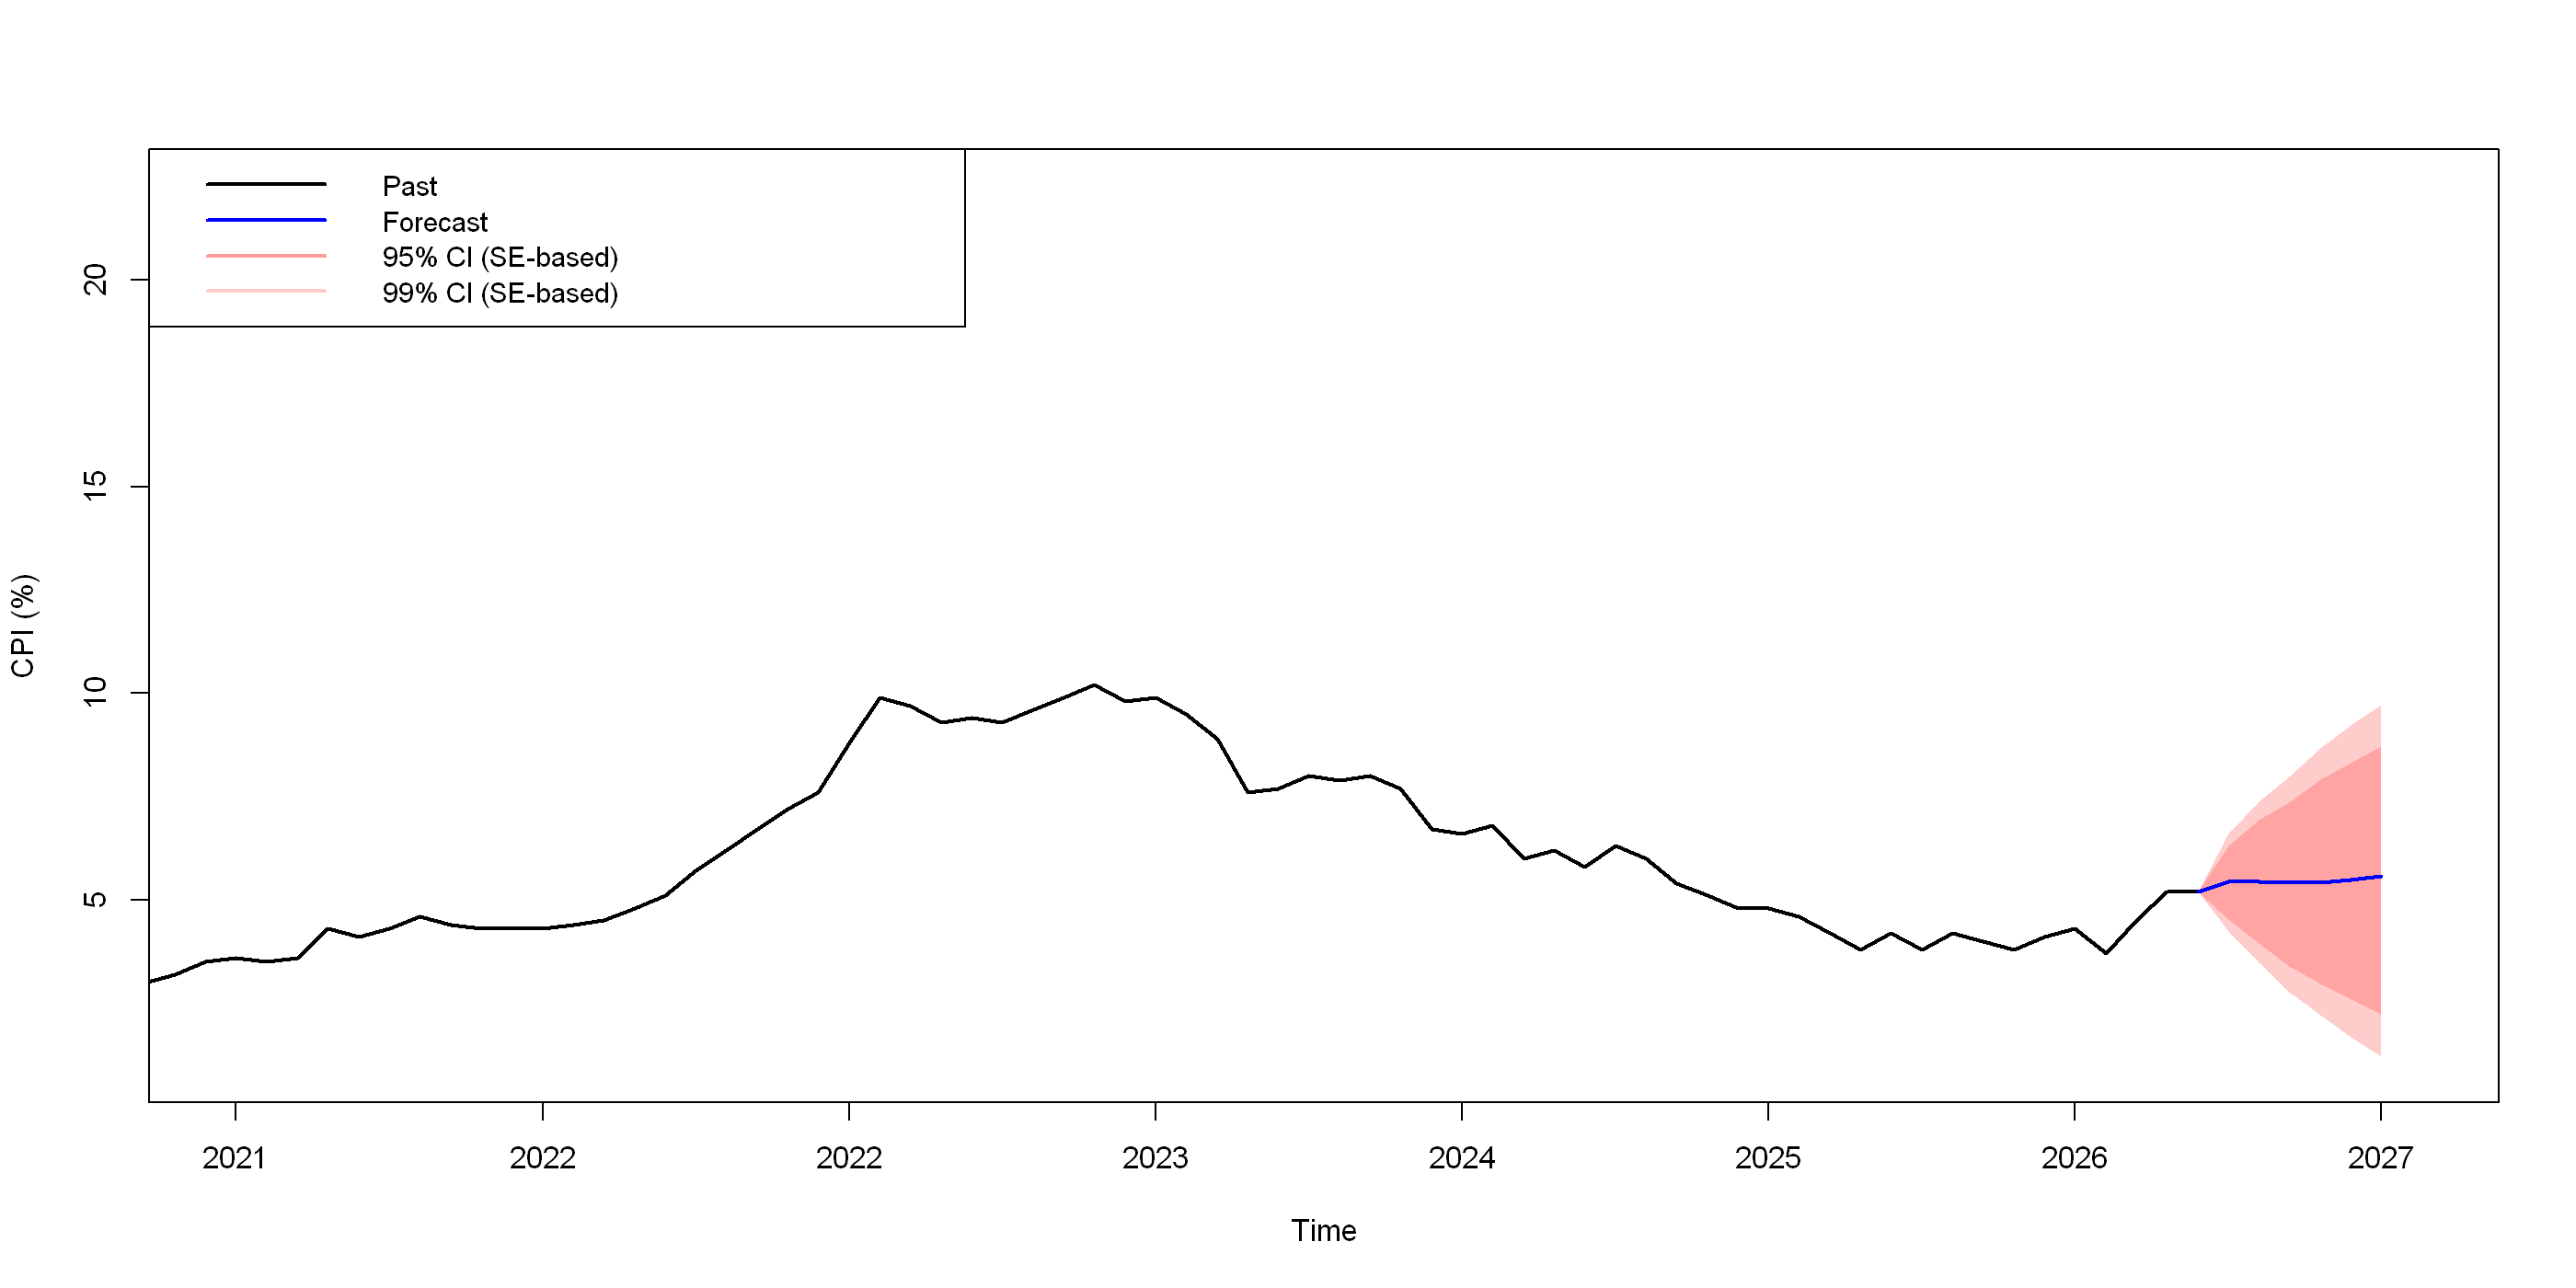